# Calculating diversity and mutation

## Calculating mutational load
To calculate mutational load, the functions from `immcantation` suite's `shazam` [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677) can be accessed via `rpy2` to work with the `dandelion` class object.

This can be run immediately after `pp.reassign_alleles` during the reannotation pre-processing stage because the required germline columns should be present in the genotyped `.tsv` file. I would recommend to run this after TIgGER [[Gadala-Maria2015]](https://www.pnas.org/content/112/8/E862), after the v_calls were corrected. Otherwise, if the reannotation was skipped, you can run it now as follows:

<b>Import modules</b>

In [1]:
import os
import dandelion as ddl
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 3

# change to tutorials directory
os.chdir("dandelion_tutorial")

<b>Read in the previously saved files</b>

In [2]:
adata = sc.read_h5ad("adata.h5ad")
adata

AnnData object with n_obs × n_vars = 25057 × 1308
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'gmm_pct_count_clusters_keep', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_genotyped_VDJ_main', 'v_call_genotyped_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'lei

<div class="alert alert-info">

Note
    
This tutorial will be trying to quantify mutations in the BCR data, and this function requires access to IMGT-formatted VDJ gene calls with allelic information. So if you have ran `vdj.simplify` before this tutorial, then it would not work. Therefore, we are loading in the `DandelionPolars` object without simplified calls.

</div>

In [3]:
vdj = ddl.read_zipddl("dandelion_results.zipddl")
vdj

Lazy Dandelion object with n_obs = 2493 and n_contigs = 5760
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blas

In [4]:
# let's rerun the find_clones and generate network steps again so we can visualise the data
ddl.tl.find_clones(vdj)
ddl.tl.generate_network(vdj)

Finding clonotypes
Using PyTorch backend with Apple Metal GPU


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 1230/1230 [00:01<00:00, 683.66it/s] 
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 576/576 [00:00<00:00, 687.75it/s]


Storing distance matrix...


Building distance matrix (batched): 100%|██████████| 19/19 [00:00<00:00, 939.24it/s]

Stored distances as CSR sparse matrix: (2493, 2493), density=0.59%
 finished: Updated Dandelion object: 
   'data', contig AIRR table
   'metadata', cell observations table
   'distances', sparse distance matrix
 (0:00:03)
Generating network
Using pre-computed distances from .distances

Computing network layout



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:00:00)


In [5]:
# let's recreate the vdj object with only the first two samples
subset_data = vdj.data[
    vdj.data["sample_id"].is_in(
        ["sc5p_v2_hs_PBMC_1k_b", "sc5p_v2_hs_PBMC_10k_b"]
    )
]
subset_data.collect()

sequence_id,sequence,rev_comp,productive,v_call,d_call,j_call,sequence_alignment,germline_alignment,junction,junction_aa,v_cigar,d_cigar,j_cigar,stop_codon,vj_in_frame,locus,junction_length,np1_length,np2_length,v_sequence_start,v_sequence_end,v_germline_start,v_germline_end,d_sequence_start,d_sequence_end,d_germline_start,d_germline_end,j_sequence_start,j_sequence_end,j_germline_start,j_germline_end,v_score,v_identity,v_support,d_score,d_identity,…,d_source,d_support_igblastn,d_score_igblastn,v_call_genotyped,germline_alignment_d_mask,sample_id,c_call,c_sequence_alignment,c_germline_alignment,c_sequence_start,c_sequence_end,c_score,c_identity,c_call_10x,junction_aa_length,fwr1_aa,fwr2_aa,fwr3_aa,fwr4_aa,cdr1_aa,cdr2_aa,cdr3_aa,sequence_alignment_aa,v_sequence_alignment_aa,d_sequence_alignment_aa,j_sequence_alignment_aa,complete_vdj,j_call_multimappers,j_call_multiplicity,j_call_sequence_start_multimappers,j_call_sequence_end_multimappers,j_call_support_multimappers,mu_count,extra,ambiguous,rearrangement_status,clone_id
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,str,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,str,str,str,str
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""TGGGGAGGAGTCAGTCCCAACCAGGACACG…","""F""","""T""","""IGKV1-33*01,IGKV1D-33*01""",null,"""IGKJ4*01""","""GACATCCAGATGACCCAGTCTCCATCCTCC…","""GACATCCAGATGACCCAGTCTCCATCCTCC…","""TGTCAACAATATGACGAACTTCCCGTCACT…","""CQQYDELPVTF""","""98S44=1X31=2X2=1X7=1X3=1X3=1X3…",null,"""384S2N22=1X5=""","""F""","""T""","""IGK""",33,2,null,99.0,382.0,1.0,332.0,null,null,null,null,385.0,412.0,3.0,30.0,363.0,0.90845,4.1800e-102,null,null,…,null,null,null,"""IGKV1-33*01,IGKV1D-33*01""","""GACATCCAGATGACCCAGTCTCCATCCTCC…","""sc5p_v2_hs_PBMC_10k_b""","""IGKC""","""CGAACTGTGGCTGCACCATCTGTCTTCATC…","""CGAACTGTGGCTGCACCATCTGTCTTCATC…",420.0,556.0,254.0,100.0,"""IGKC""",11,"""DIQMTQSPSSLSASVGDRVTITCQAT""","""VNWYQQKPGKAPKLLIY""","""NLEIGVPSRFSGRGSGTVFILTISSLQPED…","""FGGGTNVEMR""","""QDINNY""","""DAL""","""QQYDELPVT""","""DIQMTQSPSSLSASVGDRVTITCQATQDIN…","""DIQMTQSPSSLSASVGDRVTITCQATQDIN…",null,"""TFGGGTNV""",null,"""[""IGKJ4*01""]""",1.0,"""[385]""","""[412]""","""[3.56e-09]""",27.0,"""F""","""F""","""Standard""","""B_VJ_36_2_2"""
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""ATCACATAACAACCACATTCCTCCTCTAAA…","""F""","""T""","""IGHV1-69*01,IGHV1-69D*01""","""IGHD3-22*01""","""IGHJ3*02""","""CAGGTGCAGCTGGTGCAGTCTGGGGCT...…","""CAGGTGCAGCTGGTGCAGTCTGGGGCT...…","""TGTGCGACTACGTATTACTATGATAGTAGT…","""CATTYYYDSSGYYQNDAFDIW""","""115S292=""","""411S28=""","""444S50=""","""F""","""T""","""IGH""",63,4,5,116.0,407.0,1.0,316.0,412.0,439.0,1.0,28.0,445.0,494.0,1.0,50.0,456.0,1.0,3.0700e-130,54.5,1.0,…,null,1.4800e-11,54.5,"""IGHV1-69*01,IGHV1-69D*01""","""CAGGTGCAGCTGGTGCAGTCTGGGGCT...…","""sc5p_v2_hs_PBMC_10k_b""","""IGHM""","""GGAGTGCATCCGCCCCAACCCTTTTCCCCC…","""GGAGTGCATCCGCCCCAACCCTTTTCCCCC…",495.0,565.0,132.0,100.0,"""IGHM""",21,"""QVQLVQSGAEVKKPGSSVKVSCKAS""","""ISWVRQAPGQGLEWMGG""","""NYAQKFQGRVTITADESTSTAYMELSSLRS…","""WGQGTMVTVSS""","""GGTFSSYA""","""IIPIFGTA""","""ATTYYYDSSGYYQNDAFDI""","""QVQLVQSGAEVKKPGSSVKVSCKASGGTFS…","""QVQLVQSGAEVKKPGSSVKVSCKASGGTFS…","""YYYDSSGYY""","""DAFDIWGQGTMVTVSS""",null,"""[""IGHJ3*02""]""",1.0,"""[445]""","""[494]""","""[4.58e-23]""",0.0,"""F""","""F""","""Standard""","""B_VDJ_42_3_1_VJ_59_2_1"""
"""sc5p_v2_hs_PBMC_10k_b_AAACCTGT…","""AGGAGTCAGACCCTGTCAGGACACAGCATA…","""F""","""T""","""IGKV1-8*01""",null,"""IGKJ1*01""","""GCCATCCGGATGACCCAGTCTCCATCCTCA…","""GCCATCCGGATGACCCAGTCTCCATCCTCA…","""TGTCAACAGTATTATAGTTACCCTCGGACG…","""CQQYYSYPRTF""","""93S286=""",null,"""379S2N36=""","""F""","""T""","""IGK""",33,0,null,94.0,379.0,1.0,334.0,null,null,null,null,380.0,415.0,3.0,38.0,447.0,1.0,1.9500e-127,null,null,…,null,null,null,"""IGKV1-8*01""","""GCCATCCGGATGACCCAGTCTCCATCCTCA…","""sc5p_v2_

In [6]:
# create a new Dandelion class with this subset
vdj2 = ddl.Dandelion(subset_data.collect())
vdj2

Lazy Dandelion object with n_obs = 817 and n_contigs = 1894
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_blast

### `store_germline_reference`

We can store the corrected germline fasta files (after running TIgGER) in the `DandelionPolars` class as a dictionary.

In [7]:
# update the germline using the corrected files after tigger
vdj2.store_germline_reference(
    corrected="tutorial_scgp1/tutorial_scgp1_heavy_igblast_db-pass_genotype.fasta",
    germline=None,
    org="human",
)

Updating germline reference
 finished: Updated Dandelion object: 
   'germline', updated germline reference
 (0:00:00)


### `pp.create_germlines`

Then we run `pp.create_germline` to (re)create the `germline_alignment_d_mask` column in the data. This works by calling `CreateGermlines.py` with only `-d` and `-r` options. Add further arguments with `additional_args` like below for your needs. See https://changeo.readthedocs.io/en/stable/examples/germlines.html for more info.

<div class="alert alert-info">

Note
    
In order for this function to work, the V/D/J calls need to be in IMGT format with allelic information. So if you have ran `vdj.simplify` before this step, then it would not work.

</div>
    

In [8]:
ddl.pp.create_germlines(vdj2, additional_args=["--vf", "v_call_genotyped"])

Reconstructing germline sequences
Running command: CreateGermlines.py -d /var/folders/_r/j_8_fj3x28n2th3ch0ckn9c40000gt/T/tmphnqjbs65/tmp.tsv -r /var/folders/_r/j_8_fj3x28n2th3ch0ckn9c40000gt/T/tmphnqjbs65/germ.fasta --vf v_call_genotyped

     START> CreateGermlines
      FILE> tmp.tsv
GERM_TYPES> dmask
 SEQ_FIELD> sequence_alignment
   V_FIELD> v_call_genotyped
   D_FIELD> d_call
   J_FIELD> j_call
    CLONED> False

PROGRESS> 12:04:45 |####################| 100% (1,894) 0.0 min

 OUTPUT> tmp_germ-pass.tsv
RECORDS> 1894
   PASS> 1894
   FAIL> 0
    END> CreateGermlines

 finished: Returning DandelionPolars object: 
 (0:00:01)


Lazy Dandelion object with n_obs = 817 and n_contigs = 1894
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, c_call, c_sequence_alignment, c_germline_alignment, c_sequence_start, c_sequence_end, c_score, c_identity, junction_aa_length, fwr1_aa, fwr2_aa, fwr3_aa, fwr4_aa, cdr1_aa, cdr2_aa, cdr3_aa, sequence_alignment_aa, v_sequence_alignment_aa, d_sequence_alignment_aa, j_sequence_alignment_aa, complete_vdj, clone_id, v_call_

Ensure that the `germline_alignment_d_mask` column is populated or subsequent steps will fail.

In [9]:
vdj2.data[["v_call_genotyped", "germline_alignment_d_mask"]].collect()

v_call_genotyped,germline_alignment_d_mask
str,str
"""IGKV1-33*01,IGKV1D-33*01""","""GACATCCAGATGACCCAGTCTCCATCCTCC…"
"""IGHV1-69*01,IGHV1-69D*01""","""CAGGTGCAGCTGGTGCAGTCTGGGGCT...…"
"""IGKV1-8*01""","""GCCATCCGGATGACCCAGTCTCCATCCTCA…"
"""IGLV5-45*02""","""CAGGCTGTGCTGACTCAGCCGTCTTCC...…"
"""IGHV1-2*02""","""CAGGTGCAGCTGGTGCAGTCTGGGGCT...…"
…,…
"""IGHV3-23*01,IGHV3-23D*01""","""GAGGTGCAGCTGTTGGAGTCTGGGGGA...…"
"""IGKV1-8*01""","""GCCATCCGGATGACCCAGTCTCCATCCTCA…"
"""IGHV3-30-3*01""","""CAGGTGCAGCTGGTGGAGTCTGGGGGA...…"


The default behaviour is to mask the D region with Ns with option.

### `pp.quantify_mutations`

The options for `pp.quantify_mutations` are the same as the basic mutational load analysis [vignette](https://shazam.readthedocs.io/en/version-0.1.8---mutation-profiling-enhancements/vignettes/Mutation-Vignette/) [[Gupta2015]](https://academic.oup.com/bioinformatics/article/31/20/3356/195677). The default behavior is to sum all mutations scores (heavy and light chains, silent and replacement mutations) for the same cell.

Again, this function can be run immediately after `pp.reassign_alleles` on the genotyped `.tsv` files (without loading into `pandas` or `Dandelion`). Here I'm illustrating a few other options that may be useful.

In [10]:
# switching back to using the full vdj object
ddl.pp.quantify_mutations(vdj)

Quantifying mutations
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:13)


In [11]:
ddl.pp.quantify_mutations(vdj, combine=False)

Quantifying mutations
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:06)


Specifying `split_locus = True` will split up the results for the different chains.

In [12]:
ddl.pp.quantify_mutations(vdj, split_locus=True)

Quantifying mutations
 finished: Updated Dandelion object: 
   'data', contig-indexed AIRR table
   'metadata', cell-indexed observations table
 (0:00:07)


To update the `AnnData` object, simply rerun `tl.transfer`.

In [13]:
ddl.tl.transfer(adata, vdj)

Transferring network
 finished: updated `.obs` with `.metadata`
wrote active layout to `.obsm['X_vdj']`; stashed all views in `.uns['dandelion']` ('X_vdj_all', 'X_vdj_expanded')
wrote `.obsp['connectivities']` & `['distances']` from graph[0]
stashed GEX matrices in `.uns['dandelion']` ('gex_connectivities', 'gex_distances')
stashed VDJ matrices in `.uns['dandelion']` under 'vdj_connectivities_all' / '_expanded'
added `.uns['clone_id']` clone-level mapping (0:00:00)


In [14]:
adata

AnnData object with n_obs × n_vars = 25057 × 1308
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'gmm_pct_count_clusters_keep', 'scrublet_score', 'is_doublet', 'filter_rna', 'has_contig', 'productive_VDJ', 'productive_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_genotyped_VDJ_main', 'v_call_genotyped_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ', 'lei

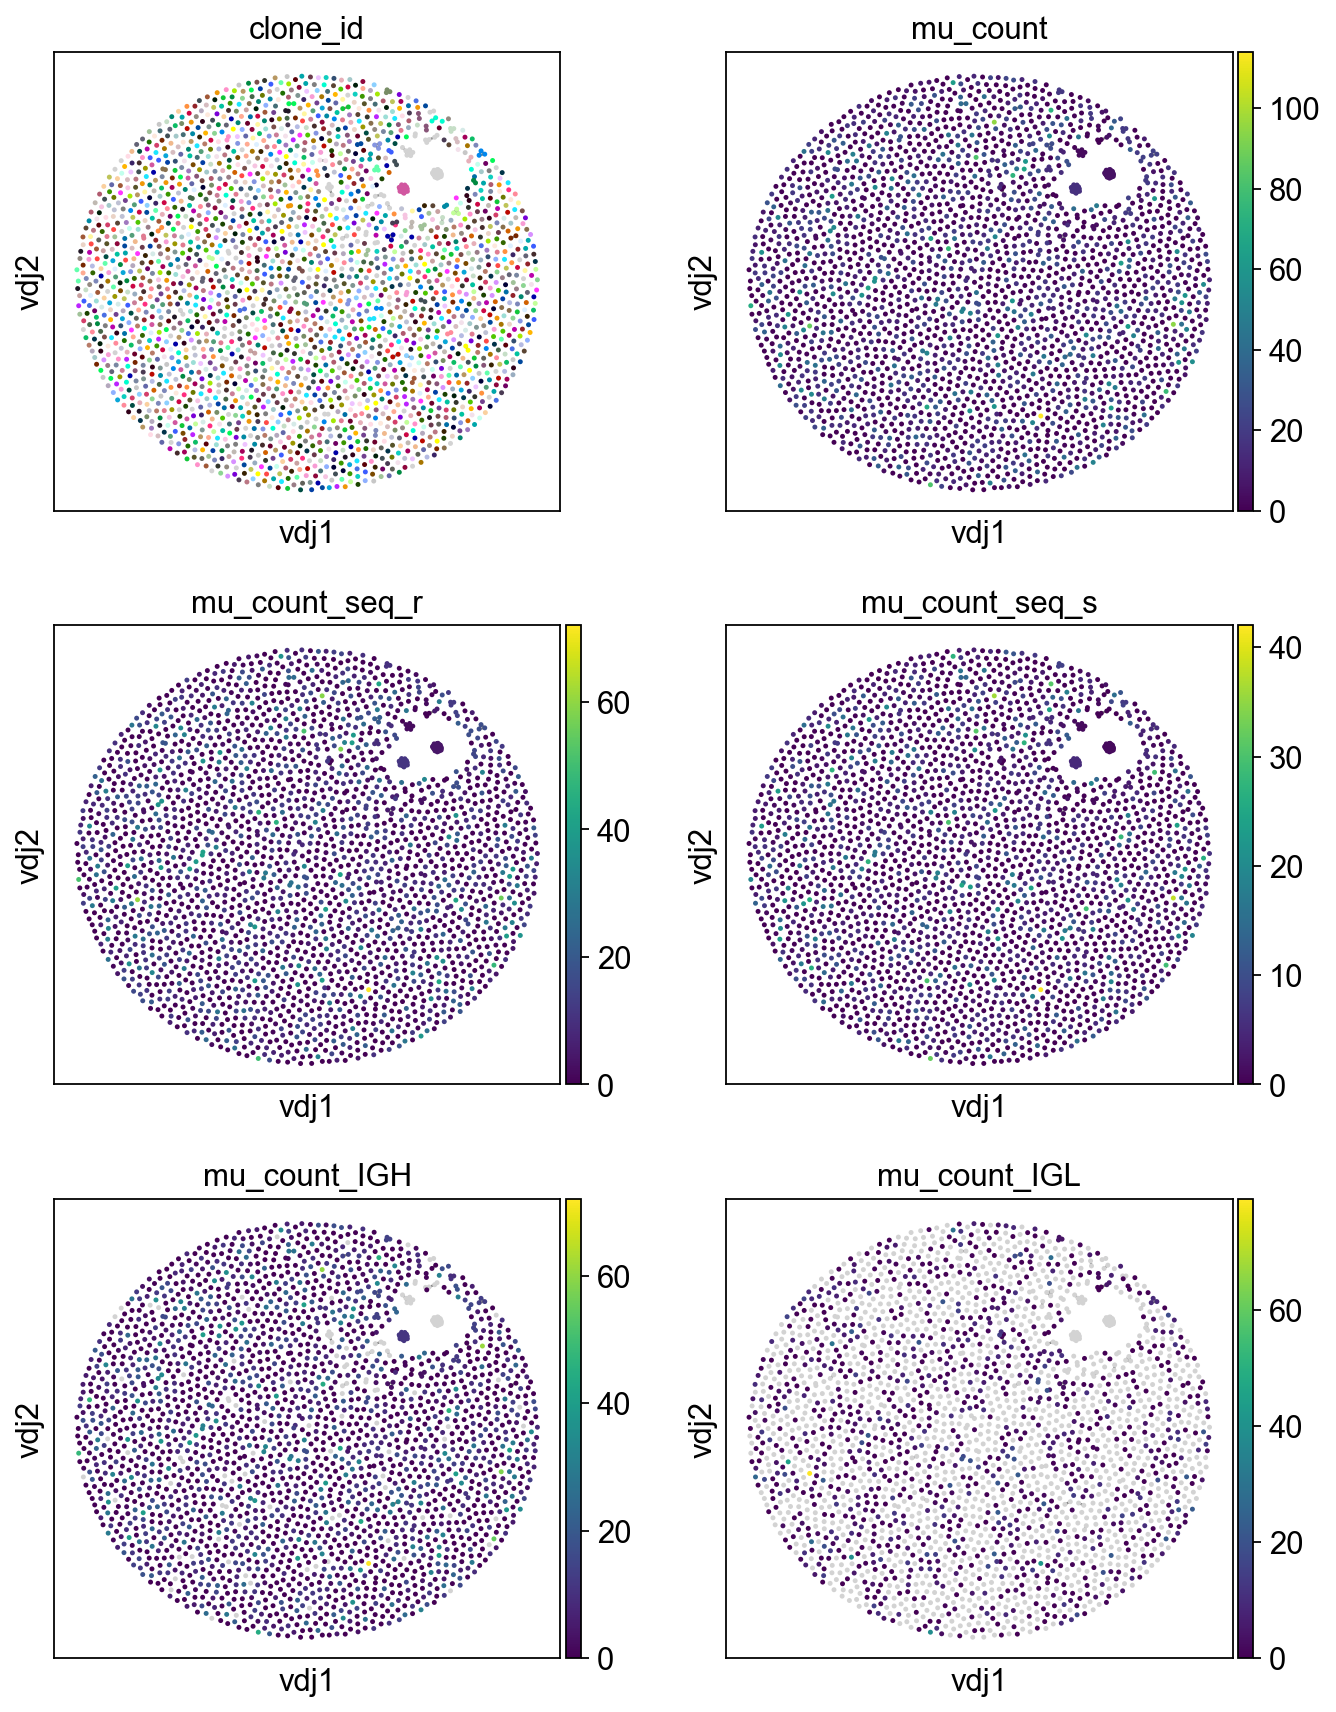

In [15]:
from scanpy.plotting.palettes import default_28, default_102

sc.set_figure_params(figsize=[4, 4])
ddl.pl.clone_network(
    adata,
    color=[
        "clone_id",
        "mu_count",
        "mu_count_seq_r",
        "mu_count_seq_s",
        "mu_count_IGH",
        "mu_count_IGL",
    ],
    ncols=2,
    legend_loc="none",
    legend_fontoutline=3,
    edges_width=1,
    palette=default_28 + default_102,
    color_map="viridis",
    size=20,
)

## Calculating diversity

`ddl.tl.clone_rarefaction`

We can use `ddl.tl.clone_rarefaction` to generate rarefaction curves for the clones. Here, I am grouping by `sampleid` in the `AnnData` object. The function will work on both `AnnData` and `Dandelion` objects. We fit the rarefaction curves using a Michaelis–Menten model and extrapolate them beyond the observed data points, with the asymptote providing an estimate of the expected number of unique clones at larger sample sizes.

Calculating rarefaction + extrapolation: 100%|██████████| 4/4 [00:00<00:00,  6.67it/s]


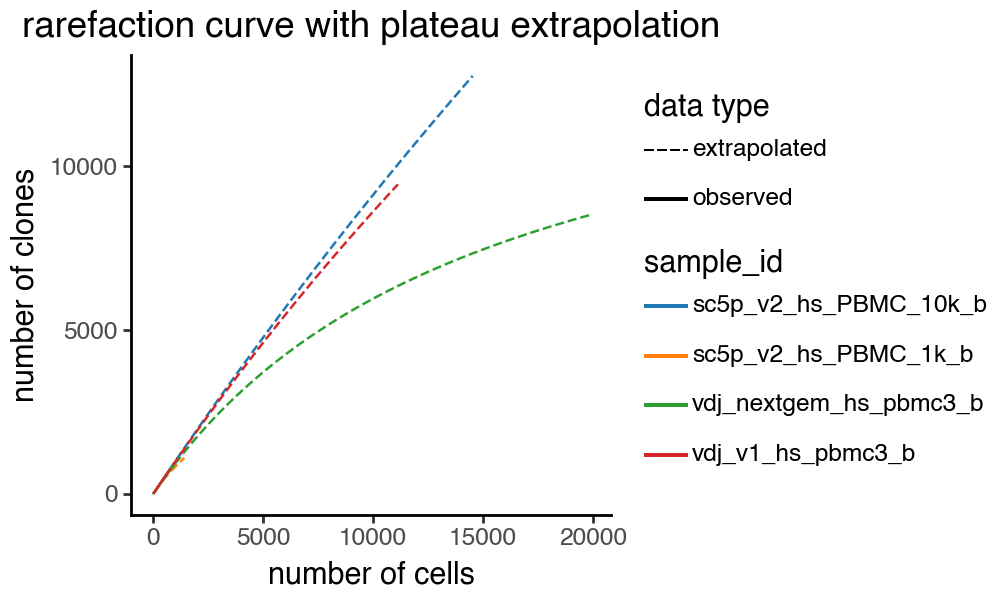

In [16]:
ddl.tl.clone_rarefaction(adata, group_by="sample_id", plot=True)

You can also use it to return the results without plotting:

In [17]:
pred = ddl.tl.clone_rarefaction(adata, group_by="sample_id", plot=False)
pred

Calculating rarefaction + extrapolation: 100%|██████████| 4/4 [00:00<00:00,  8.00it/s]


,cells,yhat,group,type,plateau
0,1,1.000089,sc5p_v2_hs_PBMC_1k_b,observed,4628.762094
1,2,1.999767,sc5p_v2_hs_PBMC_1k_b,observed,4628.762094
2,3,2.999035,sc5p_v2_hs_PBMC_1k_b,observed,4628.762094
3,4,3.997893,sc5p_v2_hs_PBMC_1k_b,observed,4628.762094
4,5,4.996342,sc5p_v2_hs_PBMC_1k_b,observed,4628.762094
...,...,...,...,...,...
46951,14535,12761.730733,sc5p_v2_hs_PBMC_10k_b,extrapolated,99353.336942
46952,14536,12762.501588,sc5p_v2_hs_PBMC_10k_b,extrapolated,99353.336942
46953,14537,12763.272431,sc5p_v2_hs_PBMC_10k_b,extrapolated,99353.336942
46954,14538,12764.043260,sc5p_v2_hs_PBMC_10k_b,extrapolated,99353.336942


Let's try and resample the data to a larger number of cells to see how many unique clones we would expect to see if we simulated to have more data.

Resampling to 5000 cells.
Finding clonotypes
Using PyTorch backend with Apple Metal GPU


Finding clones based on B cell VDJ chains using junction_aa: 100%|██████████| 1119/1119 [00:00<00:00, 1507.37it/s]
Finding clones based on B cell VJ chains using junction_aa: 100%|██████████| 538/538 [00:00<00:00, 1584.12it/s]


Storing distance matrix...


Building distance matrix (batched): 100%|██████████| 17/17 [00:00<00:00, 2129.79it/s]

Stored distances as CSR sparse matrix: (4981, 4981), density=0.59%
 finished: Updated Dandelion object: 
   'data', contig AIRR table
   'metadata', cell observations table
   'distances', sparse distance matrix
 (0:00:01)



Calculating rarefaction + extrapolation: 100%|██████████| 4/4 [00:00<00:00,  5.87it/s]


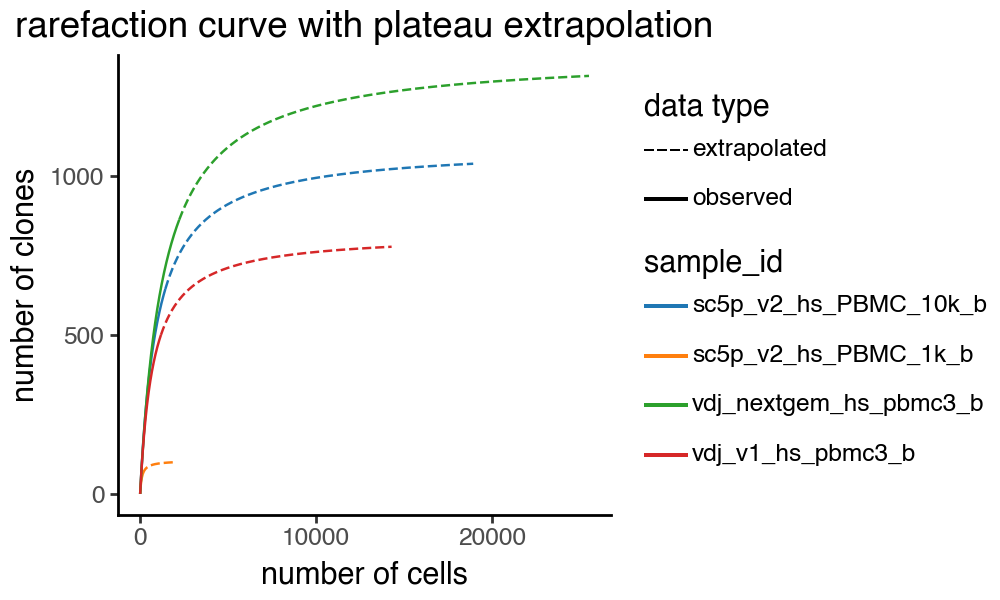

In [18]:
vdj_large = ddl.tl.vdj_sample(vdj_data=vdj, size=5000)
# re-run clone finding on the larger dataset
ddl.tl.find_clones(vdj_large)
ddl.tl.clone_rarefaction(
    vdj_large,
    group_by="sample_id",
    plot=True,
    palette=adata.uns["sample_id_colors"],
)

### `ddl.tl.clone_diversity`

`ddl.tl.clone_diversity` allows for calculation of diversity measures such as <b>Chao1</b>, <b>Shannon Entropy</b> and <b>Gini indices</b>. 

For Gini indices, we provide several types of measures, inspired by bulk BCRseq analysis methods from [[Bashford-Rogers2013]](https://genome.cshlp.org/content/23/11/1874):

The following two indices are returned with `network_metric="clone_network"`.
   
   <b>I. network cluster/clone size Gini index</b> 
    
   In a contracted BCR network (where identical BCRs are collapsed into the same node/vertex), disparity in the distribution should be correlated to the amount of mutation events i.e. larger networks should indicate more mutation events and smaller networks should indicate lesser mutation events.

   <b>II. network vertex/node size Gini index</b>
    
   In the same contracted network, we can count the number of merged/contracted nodes; nodes with higher count numbers indicate more clonal expansion. Thus, disparity in the distribution of count numbers (referred to as vertex size) should be correlated to the overall clonality i.e. clones with larger vertex sizes are more monoclonal and clones with smaller vertex sizes are more polyclonal.
    
Therefore, a Gini index of 1 on either measures repesents perfect inequality (i.e. monoclonal and highly mutated) and a value of 0 represents perfect equality (i.e. polyclonal and unmutated).

<div class="alert alert-warning">

Note

However, there are a few limitations/challenges that comes with single-cell data: 

- <b>A.</b> In the process of contracting the network, we discard the single-cell level information. <br><br>

- <b>B.</b> Contraction of network is very slow, particularly when there is a lot of clonally-related cells. <br><br>

- <b>C.</b> For the full implementation and interpretation of both measures, although more evident with cluster/clone size, it requires the BCR repertoire to be reasonably/deeply sampled and we know that this is currently limited by the low recovery from single cell data with current technologies.

</div>

Therefore, we implement a few work around options, and 'experimental' options below, to try and circumvent these issues.

Firstly, as a work around for (C), the cluster size gini index can be calculated before or after network contraction. If performing before network contraction (default), it will be calculated based on the size of subgraphs of connected components in the main graph. This will retain the single-cell information and should appropriately show the distribution of the data. If performing after network contraction, the calculation is performed after network contraction, achieving the same effect as the method for bulk BCR-seq as described above. This option can be toggled by `use_contracted` and only applies to network cluster size gini index calculation.

   <b>III. clone centrality Gini index</b> - `network_metric="clone_centrality"`
   
   Node/vertex closeness centrality indicates how tightly packed clones are (more clonally related) and thus the distribution of the number of cells connected in each clone informs on whether clones in general are more monoclonal or polyclonal.

   <b>IV. clone degree Gini index</b> - `network_metric="clone_degree"`
   
   Node/vertex degree indicates how many cells are connected to an individual cell, another indication of how clonally related cells are. However, this would also highlight cells that are in the middle of large networks but are not necessarily within clonally expanded regions (e.g. intermediate connecting cells within the minimum spanning tree).
 
   <b>V. clone size Gini index</b> - `network_metric="clone_size"`
   
   This is not to be confused with the network cluster size gini index calculation above as this doesn't rely on the network, although the values should be similar. This is just a simple implementation based on the data frame for the relevant `clone_id` column. By default, this metric is also returned when running `network_metric=clone_centrality` or `network_metric=clone_degree`.

<div class="alert alert-warning">

Note

For (I) and (II), we can specify `expanded_only` option to compute the statistic for all clones or expanded only clones. Unlike options (I) and (II), the current calculation for (III) and (IV) is largely influenced by the amount of expanded clones i.e. clones with at least 2 cells, and not affected by the number of singleton clones because singleton clones will have a value of 0 regardless.
</div>

All the diversity functions will perform bootstrap sampling with replacements to estimate confidence intervals.

In [19]:
results, raw = ddl.tl.clone_diversity(
    vdj,
    group_by="sample_id",
    method="gini",
    network_metric="clone_network",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Calculating Gini indices


Bootstrapping... sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:11<00:00, 17.48it/s]


{'cluster_gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.077792  0.026480  0.027022  0.131928
 1   sc5p_v2_hs_PBMC_10k_b  0.055194  0.021943  0.013514  0.099428
 2       vdj_v1_hs_pbmc3_b  0.071624  0.020523  0.027763  0.109797
 3    sc5p_v2_hs_PBMC_1k_b  0.260759  0.021482  0.218892  0.308065,
 'vertex_gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.006992  0.006258  0.000000  0.020548
 1   sc5p_v2_hs_PBMC_10k_b  0.001215  0.003303  0.000000  0.010274
 2       vdj_v1_hs_pbmc3_b  0.003048  0.005819  0.000000  0.019968
 3    sc5p_v2_hs_PBMC_1k_b  0.056528  0.017263  0.028376  0.092466}

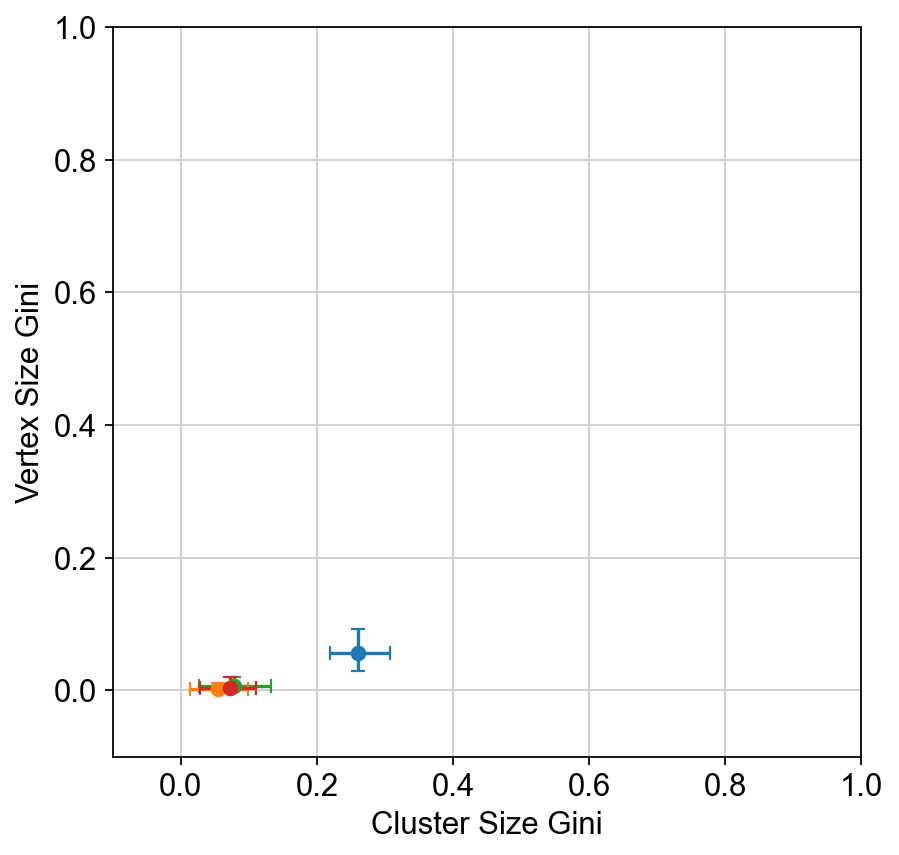

In [20]:
# set the colours
palette = dict(
    zip(adata.obs["sample_id"].cat.categories, adata.uns["sample_id_colors"])
)

# Extract relevant columns
cluster = results["cluster_gini"][
    ["sample_id", "mean", "lower_95", "upper_95"]
].rename(
    columns={
        "mean": "cluster_mean",
        "lower_95": "cluster_lower",
        "upper_95": "cluster_upper",
    }
)

vertex = results["vertex_gini"][
    ["sample_id", "mean", "lower_95", "upper_95"]
].rename(
    columns={
        "mean": "vertex_mean",
        "lower_95": "vertex_lower",
        "upper_95": "vertex_upper",
    }
)

combined = cluster.merge(vertex, on="sample_id")

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in combined.iterrows():
    color = palette[row["sample_id"]]

    # x and y CI widths
    xerr = [
        [row["cluster_mean"] - row["cluster_lower"]],
        [row["cluster_upper"] - row["cluster_mean"]],
    ]

    yerr = [
        [row["vertex_mean"] - row["vertex_lower"]],
        [row["vertex_upper"] - row["vertex_mean"]],
    ]

    ax.errorbar(
        row["cluster_mean"],
        row["vertex_mean"],
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        color=color,
        capsize=3,
    )

ax.set(
    xlabel="Cluster Size Gini",
    ylabel="Vertex Size Gini",
    xlim=(-0.1, 1),
    ylim=(-0.1, 1),
)

plt.show()

We can also plot the raw bootstrapped distributions for each sample to visualise the spread of the values.

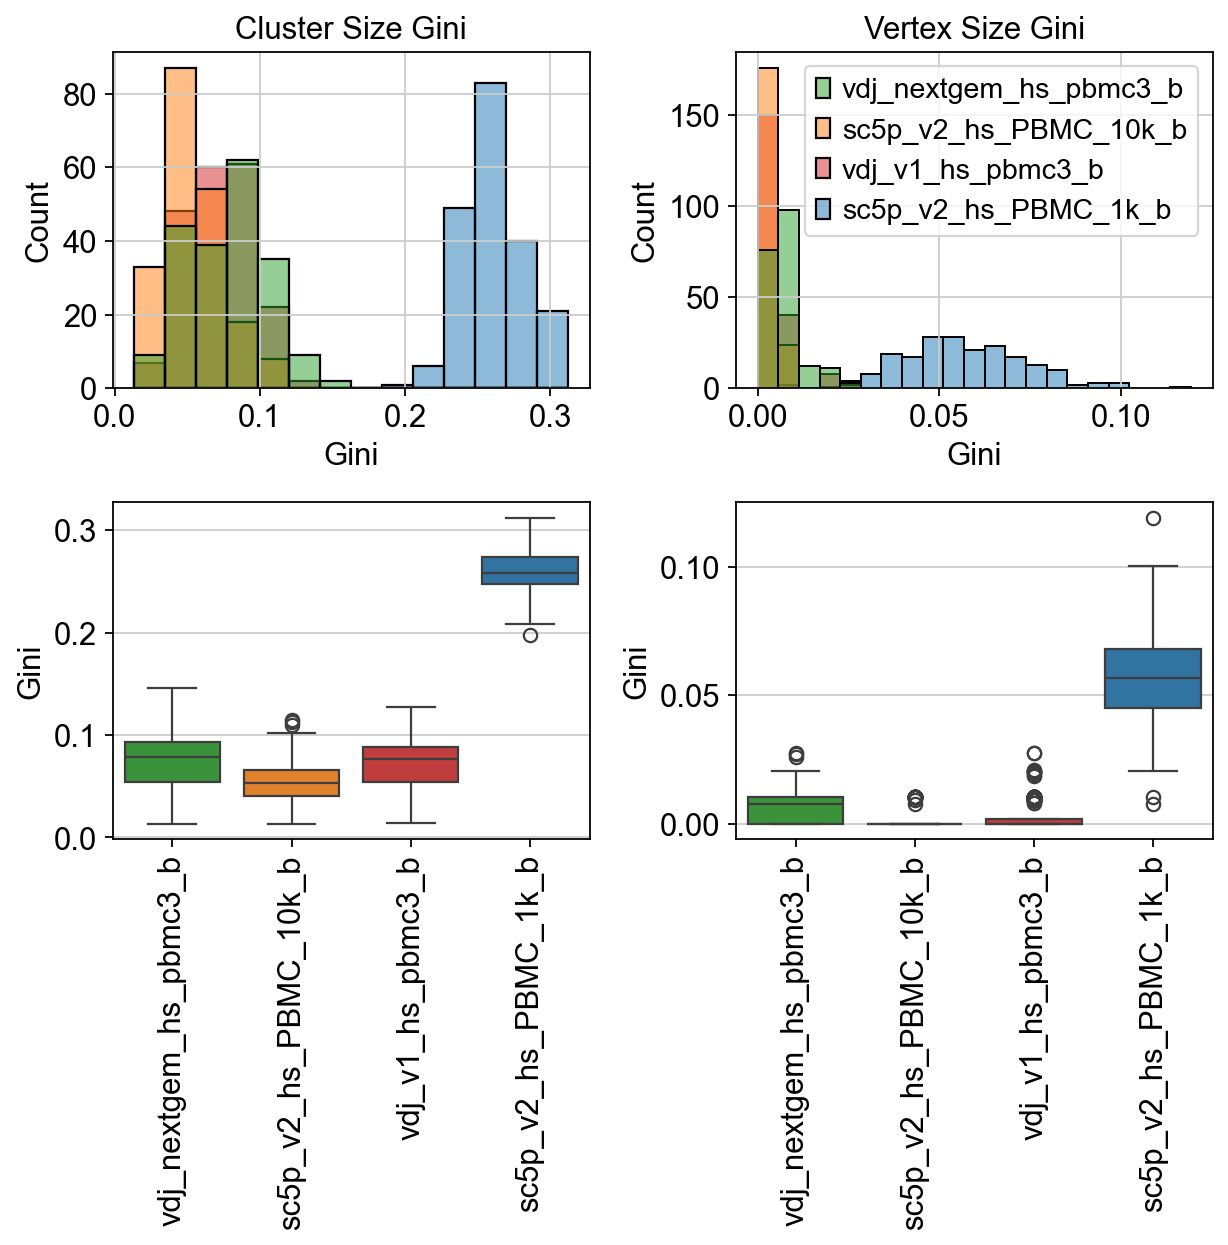

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # 1 row, 2 columns
sns.histplot(
    data=raw["cluster_gini"],
    palette=palette,
    ax=axes[0, 0],
)
sns.histplot(
    data=raw["vertex_gini"],
    palette=palette,
    ax=axes[0, 1],
)
sns.boxplot(
    data=raw["cluster_gini"],
    palette=palette,
    ax=axes[1, 0],
)
sns.boxplot(
    data=raw["vertex_gini"],
    palette=palette,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Cluster Size Gini")
axes[0, 1].set_title("Vertex Size Gini")
axes[0, 0].legend_.remove()
axes[0, 0].set_xlabel("Gini")
axes[0, 1].set_xlabel("Gini")
axes[1, 0].set_ylabel("Gini")
axes[1, 1].set_ylabel("Gini")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

With these particular samples, because there is not many expanded clones in general, the gini indices are quite low when calculated within each sample. Let's try and simulate a really large number of cells.

In [22]:
# now let's create a large sample using vdj_sample with probability weighting based on the clone size proportions so that larger clones are more likely to be sampled
ddl.tl.clone_size(vdj)
# let's materialize the vdj object to be eager so that we can use it for sampling with probabilities
vdj.to_eager()
vdj_large = ddl.tl.vdj_sample(
    vdj_data=vdj,
    size=10000,
    p=vdj.metadata["clone_id_size_prop"],
    random_state=42,
)
vdj_large

Resampling to 10000 cells.


Lazy Dandelion object with n_obs = 10000 and n_contigs = 16196
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_bl

Let's also go a bit further and introduce some mutations into the sequences to see how that affects the diversity measures.

In [23]:
from Bio.Seq import Seq
import random

NUCLEOTIDES = ["A", "T", "C", "G"]
GAP_CHARS = {".", "-", "N"}


def mutate_sequence(seq, mutation_rate=0.01):
    """Randomly mutate nucleotide sequence but skip gap characters."""
    seq_list = list(seq)

    for i, nt in enumerate(seq_list):
        # Skip gaps or unknown characters
        if nt.upper() not in NUCLEOTIDES:
            continue

        if random.random() < mutation_rate:
            seq_list[i] = random.choice(
                [n for n in NUCLEOTIDES if n != nt.upper()]
            )

    return "".join(seq_list)


def translate_cleaned_nt(seq):
    """Remove gap characters and translate clean nucleotide sequence."""
    cleaned = "".join([nt for nt in seq if nt.upper() in NUCLEOTIDES])
    return str(Seq(cleaned).translate(to_stop=False))


def mutate_dataframe(df, nt_col="junction", mutation_rate=0.01):
    """Mutate nucleotide sequences in the polars DataFrame and update amino acids."""
    aa_col = nt_col + "_aa"

    return df.with_columns(
        pl.col(nt_col)
        .map_elements(
            lambda seq: mutate_sequence(seq, mutation_rate),
            return_dtype=pl.Utf8,
        )
        .alias(nt_col),
    ).with_columns(
        pl.col(nt_col)
        .map_elements(translate_cleaned_nt, return_dtype=pl.Utf8)
        .alias(aa_col),
    )

In [24]:
# convert to eager again
vdj_large.to_eager()
mut_df = mutate_dataframe(
    vdj_large.data, nt_col="sequence_alignment", mutation_rate=0.01
)
vdj_large = ddl.Dandelion(mut_df)
vdj_large

Lazy Dandelion object with n_obs = 10000 and n_contigs = 16196
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_bl

In [25]:
# let's make an adata_large object with the same cells as vdj_large but with the same gene expression data as adata for easier comparison
adata_large = sc.AnnData(
    obs=vdj_large.metadata.collect().to_pandas().set_index("cell_id")
)
adata_large

AnnData object with n_obs × n_vars = 10000 × 0
    obs: 'clone_id', 'clone_id_rank', 'sample_id', 'productive_VDJ', 'productive_VJ', 'd_call_VDJ', 'j_call_VDJ', 'j_call_VJ', 'junction_VDJ', 'junction_VJ', 'junction_aa_VDJ', 'junction_aa_VJ', 'locus_VDJ', 'locus_VJ', 'v_call_VDJ', 'v_call_VJ', 'c_call_VDJ', 'c_call_VJ', 'umi_count_VDJ', 'umi_count_VJ', 'productive_VDJ_main', 'productive_VJ_main', 'd_call_VDJ_main', 'j_call_VDJ_main', 'j_call_VJ_main', 'junction_VDJ_main', 'junction_VJ_main', 'junction_aa_VDJ_main', 'junction_aa_VJ_main', 'locus_VDJ_main', 'locus_VJ_main', 'v_call_genotyped_VDJ_main', 'v_call_genotyped_VJ_main', 'c_call_VDJ_main', 'c_call_VJ_main', 'umi_count_VDJ_main', 'umi_count_VJ_main', 'isotype', 'isotype_main', 'isotype_status', 'locus_status', 'chain_status', 'rearrangement_status_VDJ', 'rearrangement_status_VJ'

Generating network
Calculating distance matrix  with distance_mode = 'clone'



100%|██████████| 2067/2067 [03:08<00:00, 10.94it/s]


Distances calculated in 189.16 seconds
Computing network layout
Computing expanded network layout
 finished.
   Updated Dandelion object
:    'layout', graph layout
 (0:03:25)
Transferring network
 finished: updated `.obs` with `.metadata`
wrote active layout to `.obsm['X_vdj']`; stashed all views in `.uns['dandelion']` ('X_vdj_all', 'X_vdj_expanded')
wrote `.obsp['connectivities']` & `['distances']` from graph[0]
stashed VDJ matrices in `.uns['dandelion']` under 'vdj_connectivities_all' / '_expanded'
added `.uns['clone_id']` clone-level mapping (0:00:00)


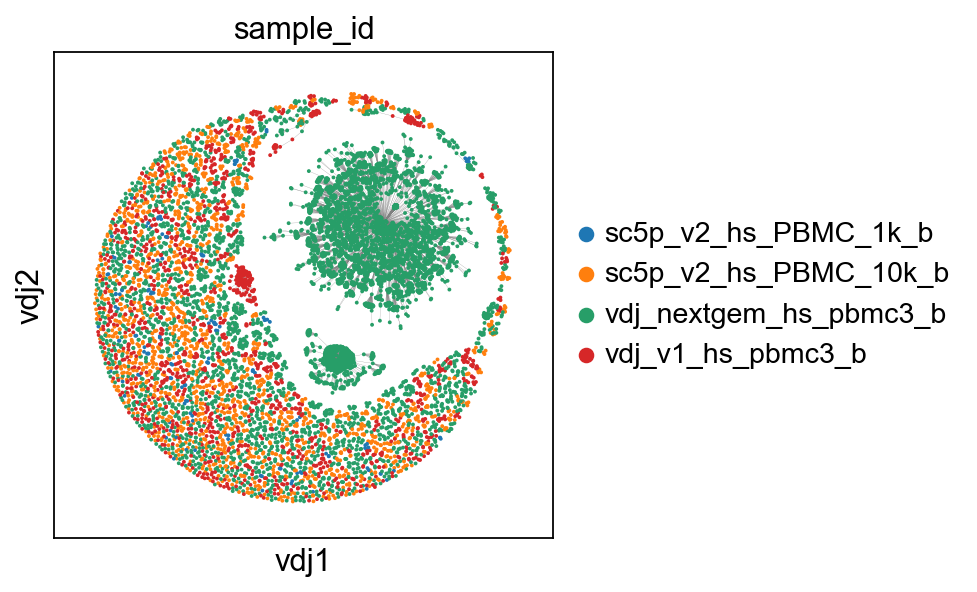

In [26]:
# what does this dataset look like?
ddl.tl.generate_network(vdj_large, use_existing_graph=False)
ddl.tl.transfer(adata_large, vdj_large)
ddl.pl.clone_network(adata_large, color=["sample_id"])

In [27]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    group_by="sample_id",
    method="gini",
    network_metric="clone_network",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Calculating Gini indices


Bootstrapping... sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:18<00:00, 10.94it/s]


{'cluster_gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.618642  0.034946  0.551683  0.683590
 1   sc5p_v2_hs_PBMC_10k_b  0.118796  0.020783  0.077379  0.158215
 2       vdj_v1_hs_pbmc3_b  0.210753  0.026595  0.159143  0.262870
 3    sc5p_v2_hs_PBMC_1k_b  0.343418  0.025372  0.291723  0.387984,
 'vertex_gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.064103  0.017553  0.034070  0.097512
 1   sc5p_v2_hs_PBMC_10k_b  0.058886  0.015900  0.027870  0.089332
 2       vdj_v1_hs_pbmc3_b  0.082548  0.015007  0.054989  0.113409
 3    sc5p_v2_hs_PBMC_1k_b  0.273749  0.020499  0.231458  0.311156}

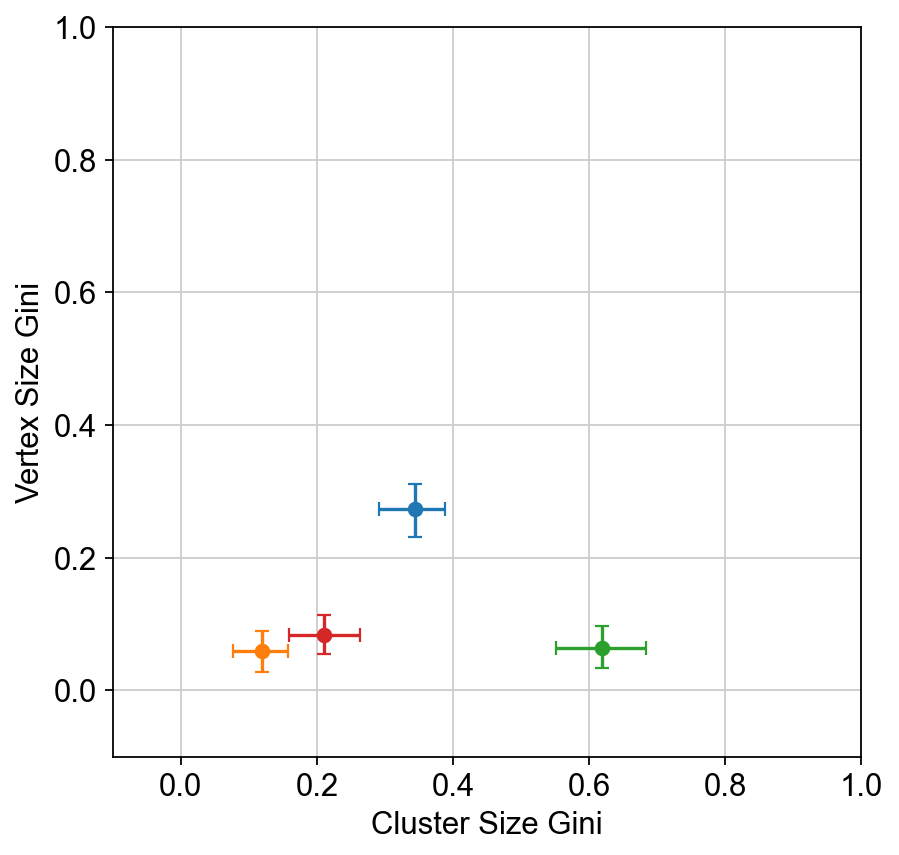

In [28]:
# Extract relevant columns
cluster = results["cluster_gini"][
    ["sample_id", "mean", "lower_95", "upper_95"]
].rename(
    columns={
        "mean": "cluster_mean",
        "lower_95": "cluster_lower",
        "upper_95": "cluster_upper",
    }
)

vertex = results["vertex_gini"][
    ["sample_id", "mean", "lower_95", "upper_95"]
].rename(
    columns={
        "mean": "vertex_mean",
        "lower_95": "vertex_lower",
        "upper_95": "vertex_upper",
    }
)

combined = cluster.merge(vertex, on="sample_id")

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in combined.iterrows():
    color = palette[row["sample_id"]]

    # x and y CI widths
    xerr = [
        [row["cluster_mean"] - row["cluster_lower"]],
        [row["cluster_upper"] - row["cluster_mean"]],
    ]

    yerr = [
        [row["vertex_mean"] - row["vertex_lower"]],
        [row["vertex_upper"] - row["vertex_mean"]],
    ]

    ax.errorbar(
        row["cluster_mean"],
        row["vertex_mean"],
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        color=color,
        capsize=3,
    )

ax.set(
    xlabel="Cluster Size Gini",
    ylabel="Vertex Size Gini",
    xlim=(-0.1, 1),
    ylim=(-0.1, 1),
)

plt.show()

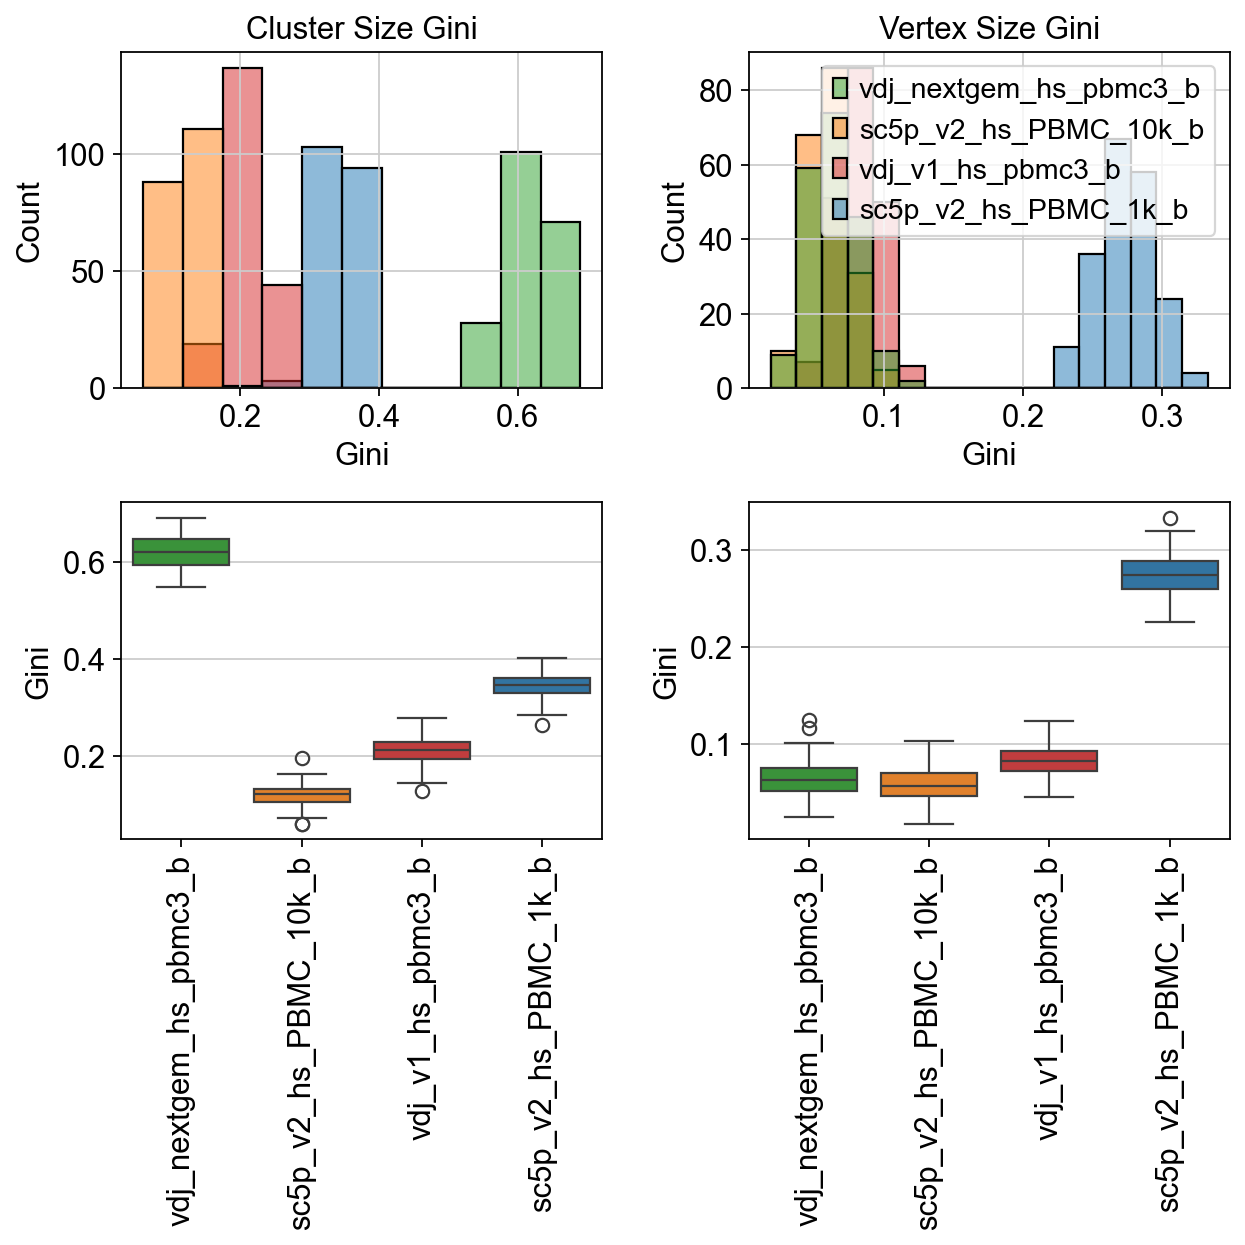

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # 1 row, 2 columns
sns.histplot(
    data=raw["cluster_gini"],
    palette=palette,
    ax=axes[0, 0],
)
sns.histplot(
    data=raw["vertex_gini"],
    palette=palette,
    ax=axes[0, 1],
)
sns.boxplot(
    data=raw["cluster_gini"],
    palette=palette,
    ax=axes[1, 0],
)
sns.boxplot(
    data=raw["vertex_gini"],
    palette=palette,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Cluster Size Gini")
axes[0, 1].set_title("Vertex Size Gini")
axes[0, 0].legend_.remove()
axes[0, 0].set_xlabel("Gini")
axes[0, 1].set_xlabel("Gini")
axes[1, 0].set_ylabel("Gini")
axes[1, 1].set_ylabel("Gini")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

Now using `network_metric = "clone_centrality"`:

In [30]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    group_by="sample_id",
    method="gini",
    network_metric="clone_centrality",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Calculating Gini indices


Bootstrapping... sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:24<00:00,  8.07it/s]


{'cluster_gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.620602  0.035471  0.546599  0.679466
 1   sc5p_v2_hs_PBMC_10k_b  0.120831  0.019493  0.084923  0.159970
 2       vdj_v1_hs_pbmc3_b  0.204496  0.025582  0.160096  0.260836
 3    sc5p_v2_hs_PBMC_1k_b  0.340098  0.026337  0.290796  0.389749,
 'vertex_gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.647583  0.048901  0.546985  0.738229
 1   sc5p_v2_hs_PBMC_10k_b  0.429156  0.214400  0.000000  0.661953
 2       vdj_v1_hs_pbmc3_b  0.601726  0.061452  0.473679  0.696882
 3    sc5p_v2_hs_PBMC_1k_b  0.546919  0.046286  0.445964  0.626161}

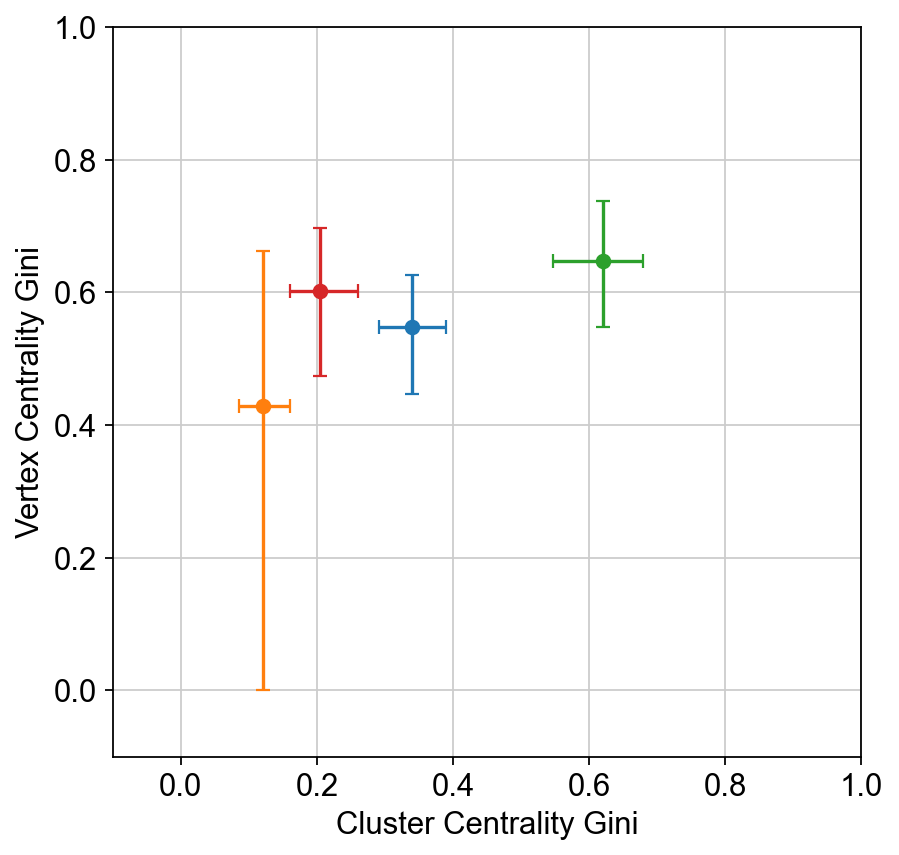

In [31]:
# Extract relevant columns
cluster = results["cluster_gini"][
    ["sample_id", "mean", "lower_95", "upper_95"]
].rename(
    columns={
        "mean": "cluster_mean",
        "lower_95": "cluster_lower",
        "upper_95": "cluster_upper",
    }
)

vertex = results["vertex_gini"][
    ["sample_id", "mean", "lower_95", "upper_95"]
].rename(
    columns={
        "mean": "vertex_mean",
        "lower_95": "vertex_lower",
        "upper_95": "vertex_upper",
    }
)

combined = cluster.merge(vertex, on="sample_id")

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in combined.iterrows():
    color = palette[row["sample_id"]]

    # x and y CI widths
    xerr = [
        [row["cluster_mean"] - row["cluster_lower"]],
        [row["cluster_upper"] - row["cluster_mean"]],
    ]

    yerr = [
        [row["vertex_mean"] - row["vertex_lower"]],
        [row["vertex_upper"] - row["vertex_mean"]],
    ]

    ax.errorbar(
        row["cluster_mean"],
        row["vertex_mean"],
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        color=color,
        capsize=3,
    )

ax.set(
    xlabel="Cluster Centrality Gini",
    ylabel="Vertex Centrality Gini",
    xlim=(-0.1, 1),
    ylim=(-0.1, 1),
)

plt.show()

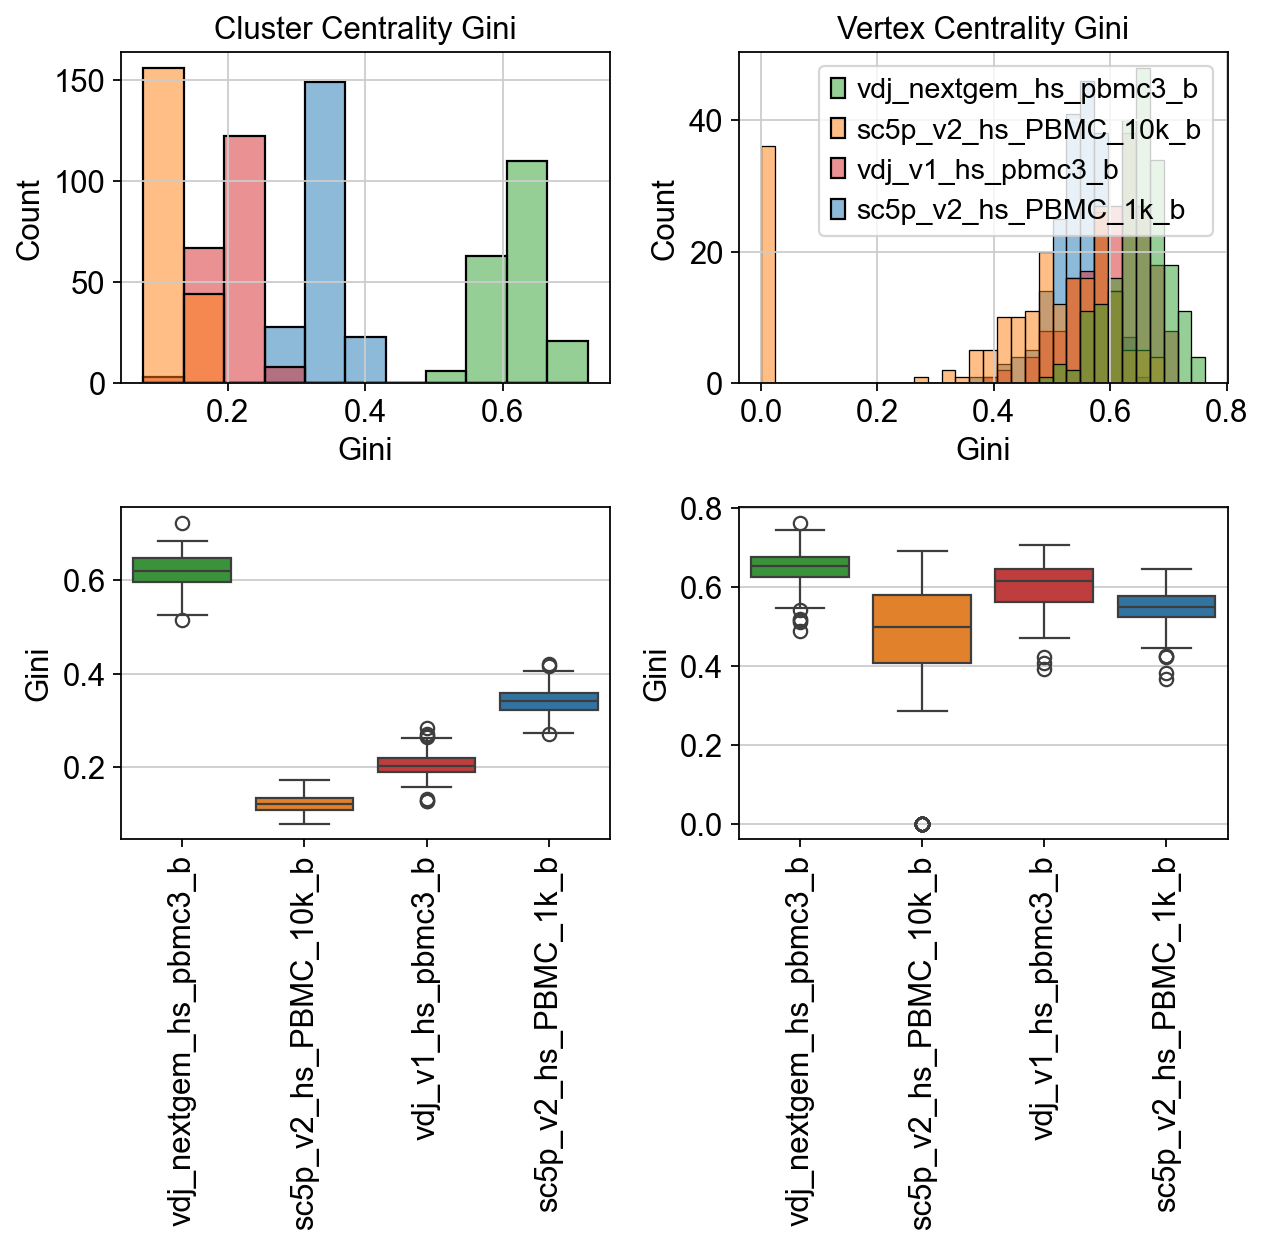

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))  # 1 row, 2 columns
sns.histplot(
    data=raw["cluster_gini"],
    palette=palette,
    ax=axes[0, 0],
)
sns.histplot(
    data=raw["vertex_gini"],
    palette=palette,
    ax=axes[0, 1],
)
sns.boxplot(
    data=raw["cluster_gini"],
    palette=palette,
    ax=axes[1, 0],
)
sns.boxplot(
    data=raw["vertex_gini"],
    palette=palette,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Cluster Centrality Gini")
axes[0, 1].set_title("Vertex Centrality Gini")
axes[0, 0].legend_.remove()
axes[0, 0].set_xlabel("Gini")
axes[0, 1].set_xlabel("Gini")
axes[1, 0].set_ylabel("Gini")
axes[1, 1].set_ylabel("Gini")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=90)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

Finally, let's try the other diversity methods. `chao1` is an estimator based on abundance.

In [33]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    group_by="sample_id",
    method="chao1",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:00<00:00, 3534.69it/s]


{'chao1':                 sample_id        mean         std    lower_95   upper_95
 0  vdj_nextgem_hs_pbmc3_b  480.623929  308.798885  166.964286  1382.3000
 1   sc5p_v2_hs_PBMC_10k_b  536.985934  151.950222  334.956758   909.1750
 2       vdj_v1_hs_pbmc3_b  386.942633   95.091620  258.732566   597.4225
 3    sc5p_v2_hs_PBMC_1k_b   60.128945    6.460919   50.642421    75.2550}

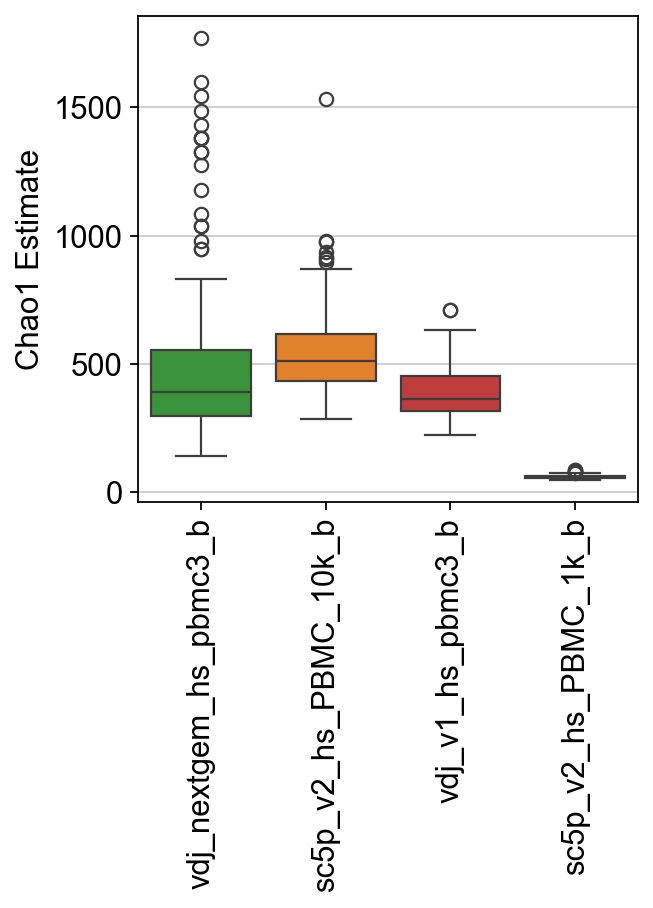

In [34]:
ax = sns.boxplot(
    data=raw["chao1"],
    palette=palette,
)
ax.set_ylabel("Chao1 Estimate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

For Shannon Entropy, we can calculate a normalized (inspired by [scirpy's function](https://icbi-lab.github.io/scirpy/generated/scirpy.tl.alpha_diversity.html?highlight=diversity#scirpy.tl.alpha_diversity)) and non-normalized value.

In [35]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    group_by="sample_id",
    method="shannon",
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:00<00:00, 4637.66it/s]


{'shannon':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.588768  0.035703  0.514778  0.654629
 1   sc5p_v2_hs_PBMC_10k_b  0.990040  0.002148  0.985187  0.993812
 2       vdj_v1_hs_pbmc3_b  0.964738  0.009096  0.944902  0.980081
 3    sc5p_v2_hs_PBMC_1k_b  0.949499  0.008830  0.931595  0.964314}

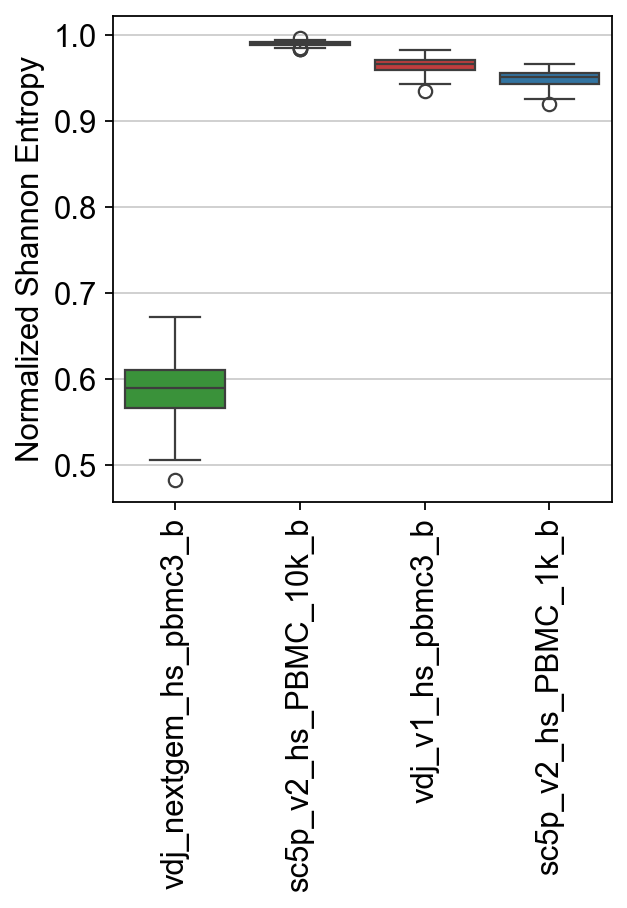

In [36]:
ax = sns.boxplot(
    data=raw["shannon"],
    palette=palette,
)
ax.set_ylabel("Normalized Shannon Entropy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

In [37]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    group_by="sample_id",
    method="shannon",
    n_boot=200,
    n_cpus=8,
    verbose=True,
    normalize=False,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:00<00:00, 3821.03it/s]


{'shannon':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  3.379172  0.268651  2.807275  3.863655
 1   sc5p_v2_hs_PBMC_10k_b  6.891744  0.051463  6.785677  7.000746
 2       vdj_v1_hs_pbmc3_b  6.542756  0.106183  6.350598  6.752533
 3    sc5p_v2_hs_PBMC_1k_b  5.391804  0.093494  5.193158  5.561164}

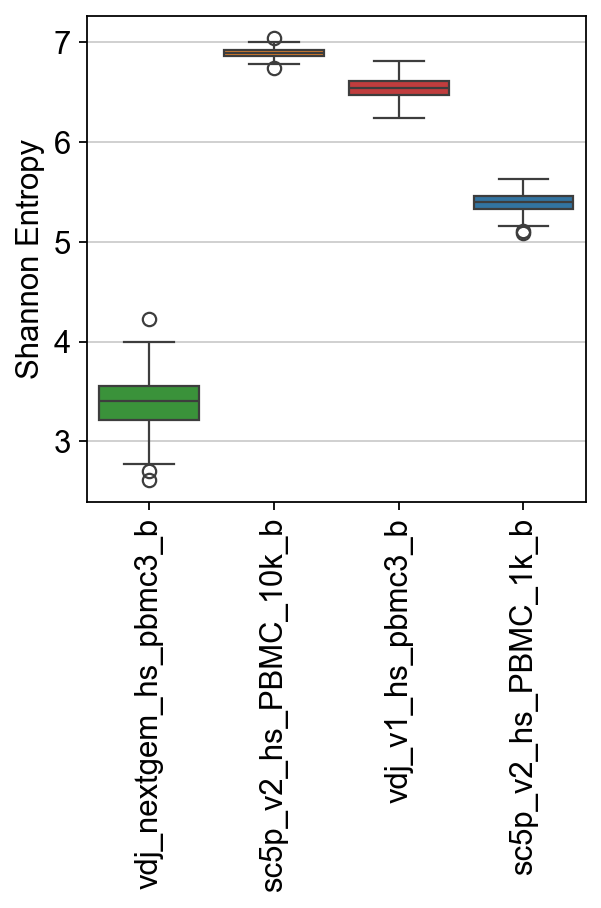

In [38]:
ax = sns.boxplot(
    data=raw["shannon"],
    palette=palette,
)
ax.set_ylabel("Shannon Entropy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

There's also a `gini` method that doesn't require network construction, which should be faster to compute.

In [39]:
results, raw = ddl.tl.clone_diversity(
    vdj_large,
    group_by="sample_id",
    method="gini",
    use_network=False,
    n_boot=200,
    n_cpus=8,
    verbose=True,
)
results

Bootstrapping… sc5p_v2_hs_PBMC_1k_b: 100%|██████████| 200/200 [00:00<00:00, 4372.55it/s]


{'gini':                 sample_id      mean       std  lower_95  upper_95
 0  vdj_nextgem_hs_pbmc3_b  0.619105  0.036831  0.537997  0.684507
 1   sc5p_v2_hs_PBMC_10k_b  0.113060  0.019933  0.076086  0.148148
 2       vdj_v1_hs_pbmc3_b  0.203305  0.026655  0.148188  0.253150
 3    sc5p_v2_hs_PBMC_1k_b  0.344809  0.025892  0.294989  0.392928}

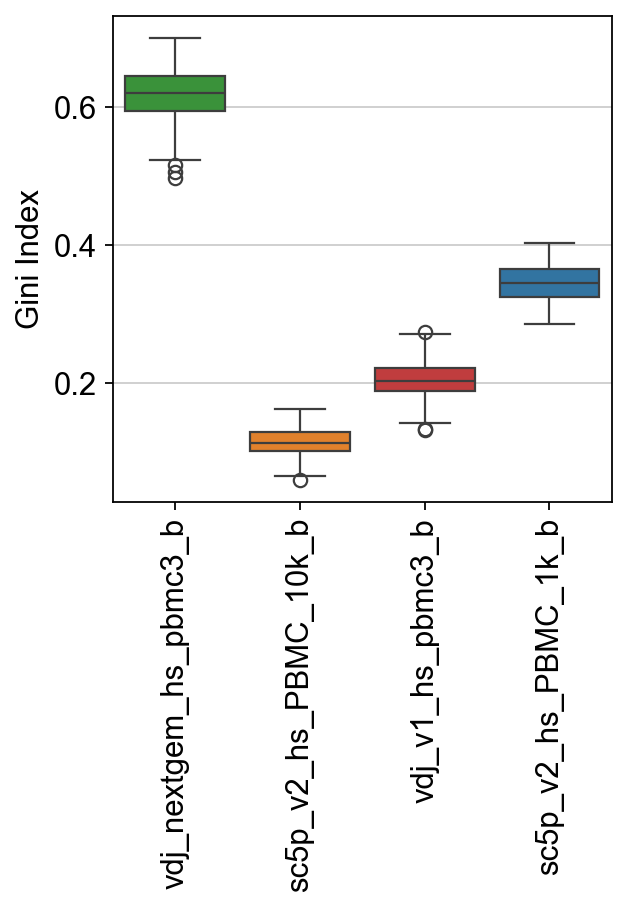

In [40]:
ax = sns.boxplot(
    data=raw["gini"],
    palette=palette,
)
ax.set_ylabel("Gini Index")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

## Intraclonal Diversity Metrics Per Clonotype

The new standalone tools API includes `ddl.tl.intraclonal_diversity`, which summarizes within-clonotype network structure and sub-community organization.

The table below reports one row per clonotype and keeps `clone_id` and `clone_size` as the first two columns for easier interpretation.

In [41]:
intraclonal_metrics = ddl.tl.intraclonal_diversity(
    vdj_large,
    min_cells=20,
    top_n=10,
    fast=True,
    n_sources=16,
    betweenness_k=32,
    random_state=42,
)

intraclonal_metrics.head(10)

,clone_id,clone_size,n_nodes,n_edges,largest_community_fraction,n_communities_greedy,modularity_greedy,density,mean_degree,var_degree,degree_assortativity,transitivity,average_clustering,diameter_component,average_shortest_path_component,mean_betweenness,mean_closeness,max_pagerank,mode
0,B_VJ_111_1_1,3802,3802,47080,0.111520,451,2.546650e-02,0.006516,24.765913,6279.975187,0.368569,0.973183,0.133576,6.0,0.822991,2.861846e+83,1.437943,0.041783,fast
1,B_VDJ_153_1_1_VJ_111_1_1,526,526,526,0.695817,36,1.550320e-08,0.003810,2.000000,303.307985,-0.623228,0.000037,0.003802,19.0,10.745890,2.761640e-03,0.094868,0.342862,fast
2,B_VJ_120_3_1,104,104,118,0.567308,15,8.677686e-02,0.022031,2.269231,49.600592,-0.495493,0.038476,0.057749,11.0,5.099138,5.892315e-02,0.206916,0.208338,fast
3,B_VJ_212_3_1,52,52,54,0.500000,3,2.827778e-09,0.040724,2.076923,18.417160,-0.730297,0.022346,0.057857,8.0,3.660000,6.375520e-02,0.301893,0.281320,fast
4,B_VJ_176_2_1,47,47,46,0.319149,4,5.000000e-01,0.042553,1.957447,8.083296,-0.677127,0.000000,0.000000,11.0,4.628571,7.802198e-02,0.243146,0.454612,fast
5,B_VDJ_168_7_3_VJ_174_3_2,22,22,21,0.409091,5,4.591631e-01,0.090909,1.909091,5.900826,-0.526667,0.000000,0.000000,22.0,14.000000,1.111111e-01,0.075248,0.468470,fast
6,B_VDJ_212_5_1_VJ_167_3_1,22,22,21,0.909091,2,5.915760e-02,0.090909,1.909091,13.991736,-0.839487,0.000000,0.000000,19.0,11.407895,5.497076e-02,0.092065,0.444462,fast
7,B_VDJ_202_9_2_VJ_123_2_1,21,21,20,0.904762,2,5.016435e-02,0.095238,1.904762,14.657596,-0.913364,0.000000,0.000000,25.0,16.055556,5.263158e-02,0.065396,0.463731,fast
8,B_VDJ_202_9_2_VJ_43_3_1,21,21,20,0.904762,2,5.016435e-02,0.095238,1.904762,14.657596,-0.913364,0.000000,0.000000,25.0,16.055556,5.263158e-02,0.065396,0.463731,fast
9,B_VDJ_225_3_1_VJ_143_2_1,21,21,20,0.904762,2,6.924370e-02,0.095238,1.904762,14.657596,-0.913364,0.000000,0.000000,22.0,14.625000,5.263158e-02,0.070934,0.463731,fast


### Map Intraclonal Metrics To Cells In adata_large

To visualize these clonotype-level metrics on the clone network, we map each cell in `adata_large.obs` to the corresponding (`sample_id`, `clone_id`) row from `intraclonal_diversity`.

In [ ]:
intraclonal_metrics = ddl.tl.intraclonal_diversity(
    vdj_large,
    group_by="sample_id",
    min_cells=2,
    top_n=None,
    fast=True,
    n_sources=16,
    betweenness_k=32,
    random_state=42,
)

meta_large = vdj_large.metadata
if hasattr(meta_large, "collect"):
    meta_large = meta_large.collect().to_pandas()

cell_lookup = (
    meta_large[["cell_id", "sample_id", "clone_id"]]
    .drop_duplicates(subset=["cell_id"], keep="first")
    .copy()
)

# Expand pipe-delimited clone_ids so each cell gets one row per part,
# matching the same smart-split logic used inside intraclonal_diversity.
# A cell with clone_id "A|B" becomes two rows: one for "A", one for "B".
# After the join we de-duplicate back to one row per cell, keeping the
# first matched metric row (they will be the same if the clone was not
# split, and meaningfully different rows if it was — in which case you
# may want to revisit which label to keep).
cell_lookup["clone_id_parts"] = (
    cell_lookup["clone_id"]
    .str.split("|")
    .apply(lambda parts: [p.strip() for p in parts if p.strip()])
)
cell_lookup_expanded = cell_lookup.explode("clone_id_parts").rename(
    columns={"clone_id": "original_clone_id", "clone_id_parts": "clone_id"}
)

metric_lookup = intraclonal_metrics.set_index(["sample_id", "clone_id"])

cell_metrics = (
    cell_lookup_expanded.join(metric_lookup, on=["sample_id", "clone_id"])
    # Drop back to one row per cell; if a cell matched multiple metric rows
    # (genuine split clone), keep the first.
    .drop_duplicates(subset=["cell_id"], keep="first").set_index("cell_id")
)

metric_cols = [
    c
    for c in cell_metrics.columns
    if c not in ("sample_id", "clone_id", "original_clone_id")
]

for col in metric_cols:
    adata_large.obs[col] = cell_metrics.reindex(adata_large.obs_names)[col]

In [66]:
import numpy as np

np.max(intraclonal_metrics["degree_assortativity"])

np.float64(0.3685694921287615)

In [61]:
ddl.tl.clone_view(adata_large, mode="expanded")

In [74]:
adata_large.obs[["degree_assortativity", "clone_size"]]

,degree_assortativity,clone_size
cell_id,,
sc5p_v2_hs_PBMC_10k_b_AAAGTAGCAGATCCAT,NaN,NaN
sc5p_v2_hs_PBMC_10k_b_AAAGTAGGTACAAGTA,NaN,NaN
sc5p_v2_hs_PBMC_10k_b_AACCATGCAAGCTGTT,NaN,NaN
sc5p_v2_hs_PBMC_10k_b_AACCATGTCAGTCCCT,NaN,NaN
sc5p_v2_hs_PBMC_10k_b_AACCATGTCTAGCACA,NaN,NaN
...,...,...
vdj_v1_hs_pbmc3_b_CAGTCCTAGGGATGGG-1,NaN,NaN
vdj_v1_hs_pbmc3_b_CTCGTACCACGGACAA,NaN,NaN
vdj_v1_hs_pbmc3_b_CTCGTACCACGGACAA-1,NaN,NaN


In [ ]:
mask = (
    adata_large.obs["degree_assortativity"].isna()
    ^ adata_large.obs["clone_size"].isna()
)
count = mask.sum()

In [ ]:
adata_large.obs[mask][["clone_size"]]

In [79]:
adata_large.obs[mask][["degree_assortativity", "clone_size"]]

,degree_assortativity,clone_size
cell_id,,
sc5p_v2_hs_PBMC_10k_b_TCGGGACCAGCTGCAC,NaN,2.0
sc5p_v2_hs_PBMC_10k_b_TCGGGACCAGCTGCAC-1,NaN,2.0
sc5p_v2_hs_PBMC_10k_b_CACATAGGTCGAATCT,NaN,2.0
sc5p_v2_hs_PBMC_10k_b_CACATAGGTCGAATCT-1,NaN,2.0
vdj_v1_hs_pbmc3_b_GGGACCTAGTGCGATG,NaN,2.0
...,...,...
vdj_nextgem_hs_pbmc3_b_ACACCAATCCACTGGG-1,NaN,2.0
vdj_v1_hs_pbmc3_b_ACCGTAAAGAAACGCC,NaN,2.0
vdj_v1_hs_pbmc3_b_ACCGTAAAGAAACGCC-1,NaN,2.0


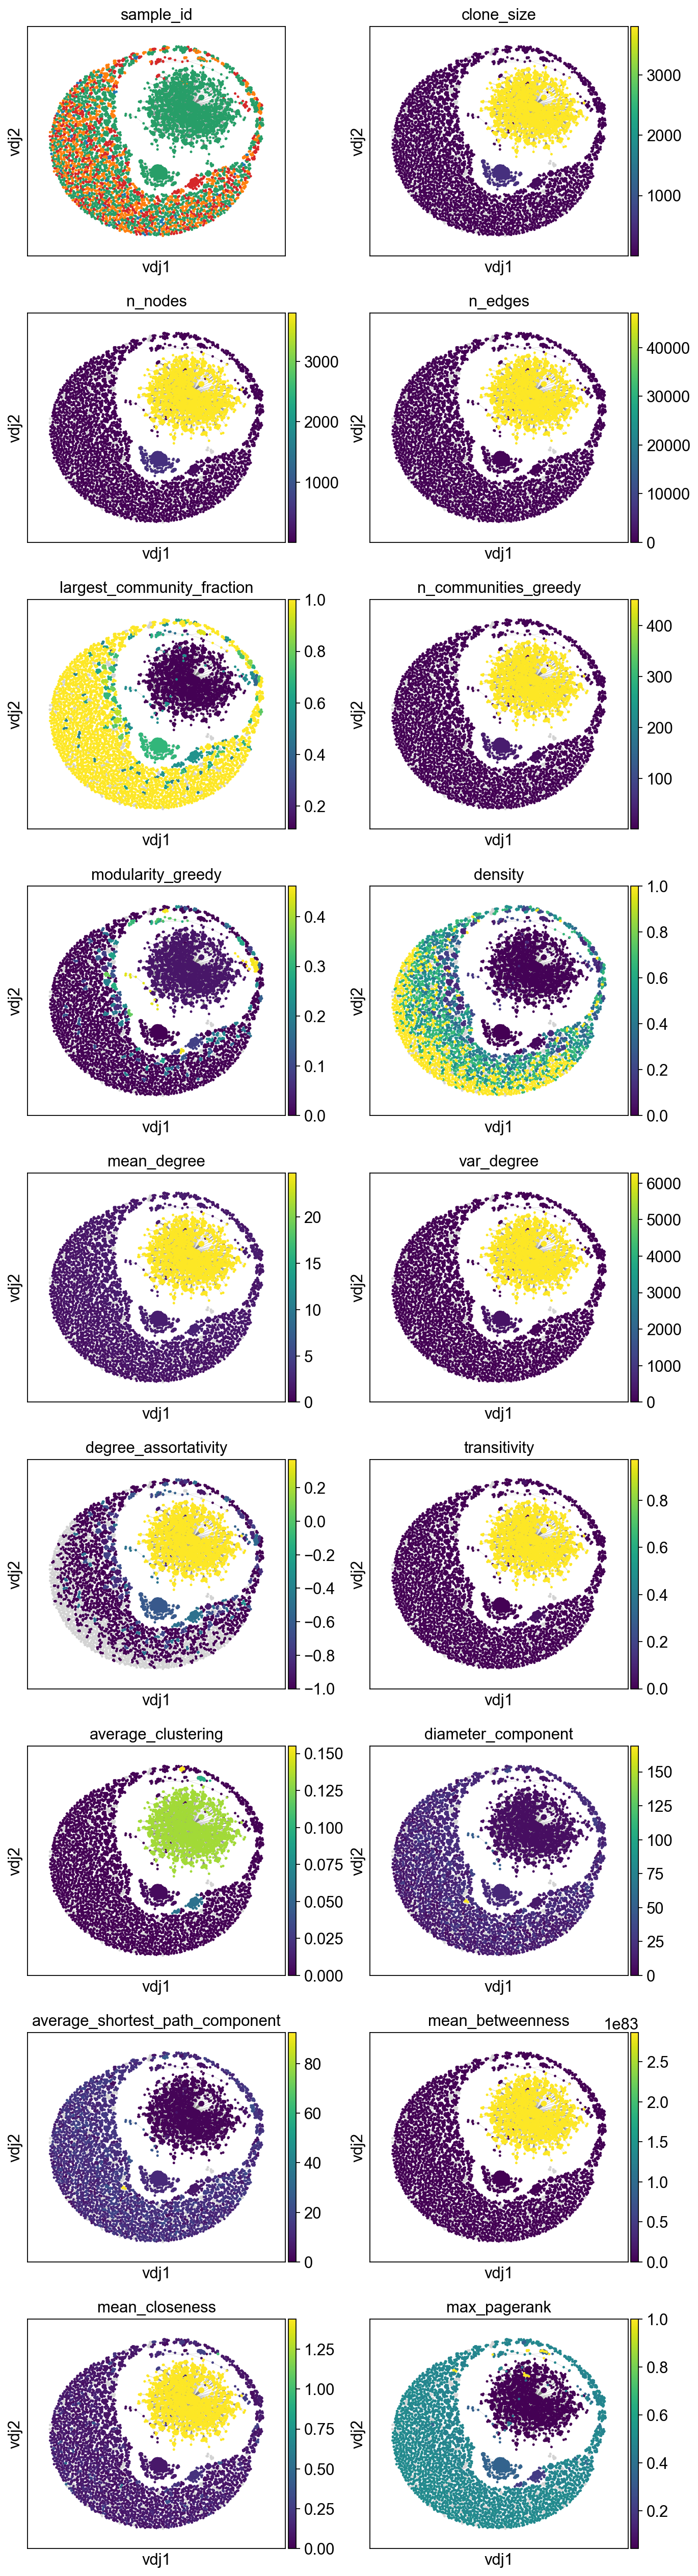

In [75]:
ddl.pl.clone_network(
    adata_large,
    color=[
        "sample_id",
        "clone_size",
        "n_nodes",
        "n_edges",
        "largest_community_fraction",
        "n_communities_greedy",
        "modularity_greedy",
        "density",
        "mean_degree",
        "var_degree",
        "degree_assortativity",
        "transitivity",
        "average_clustering",
        "diameter_component",
        "average_shortest_path_component",
        "mean_betweenness",
        "mean_closeness",
        "max_pagerank",
    ],
    ncols=2,
    legend_loc="none",
    color_map="viridis",
    size=20,
)

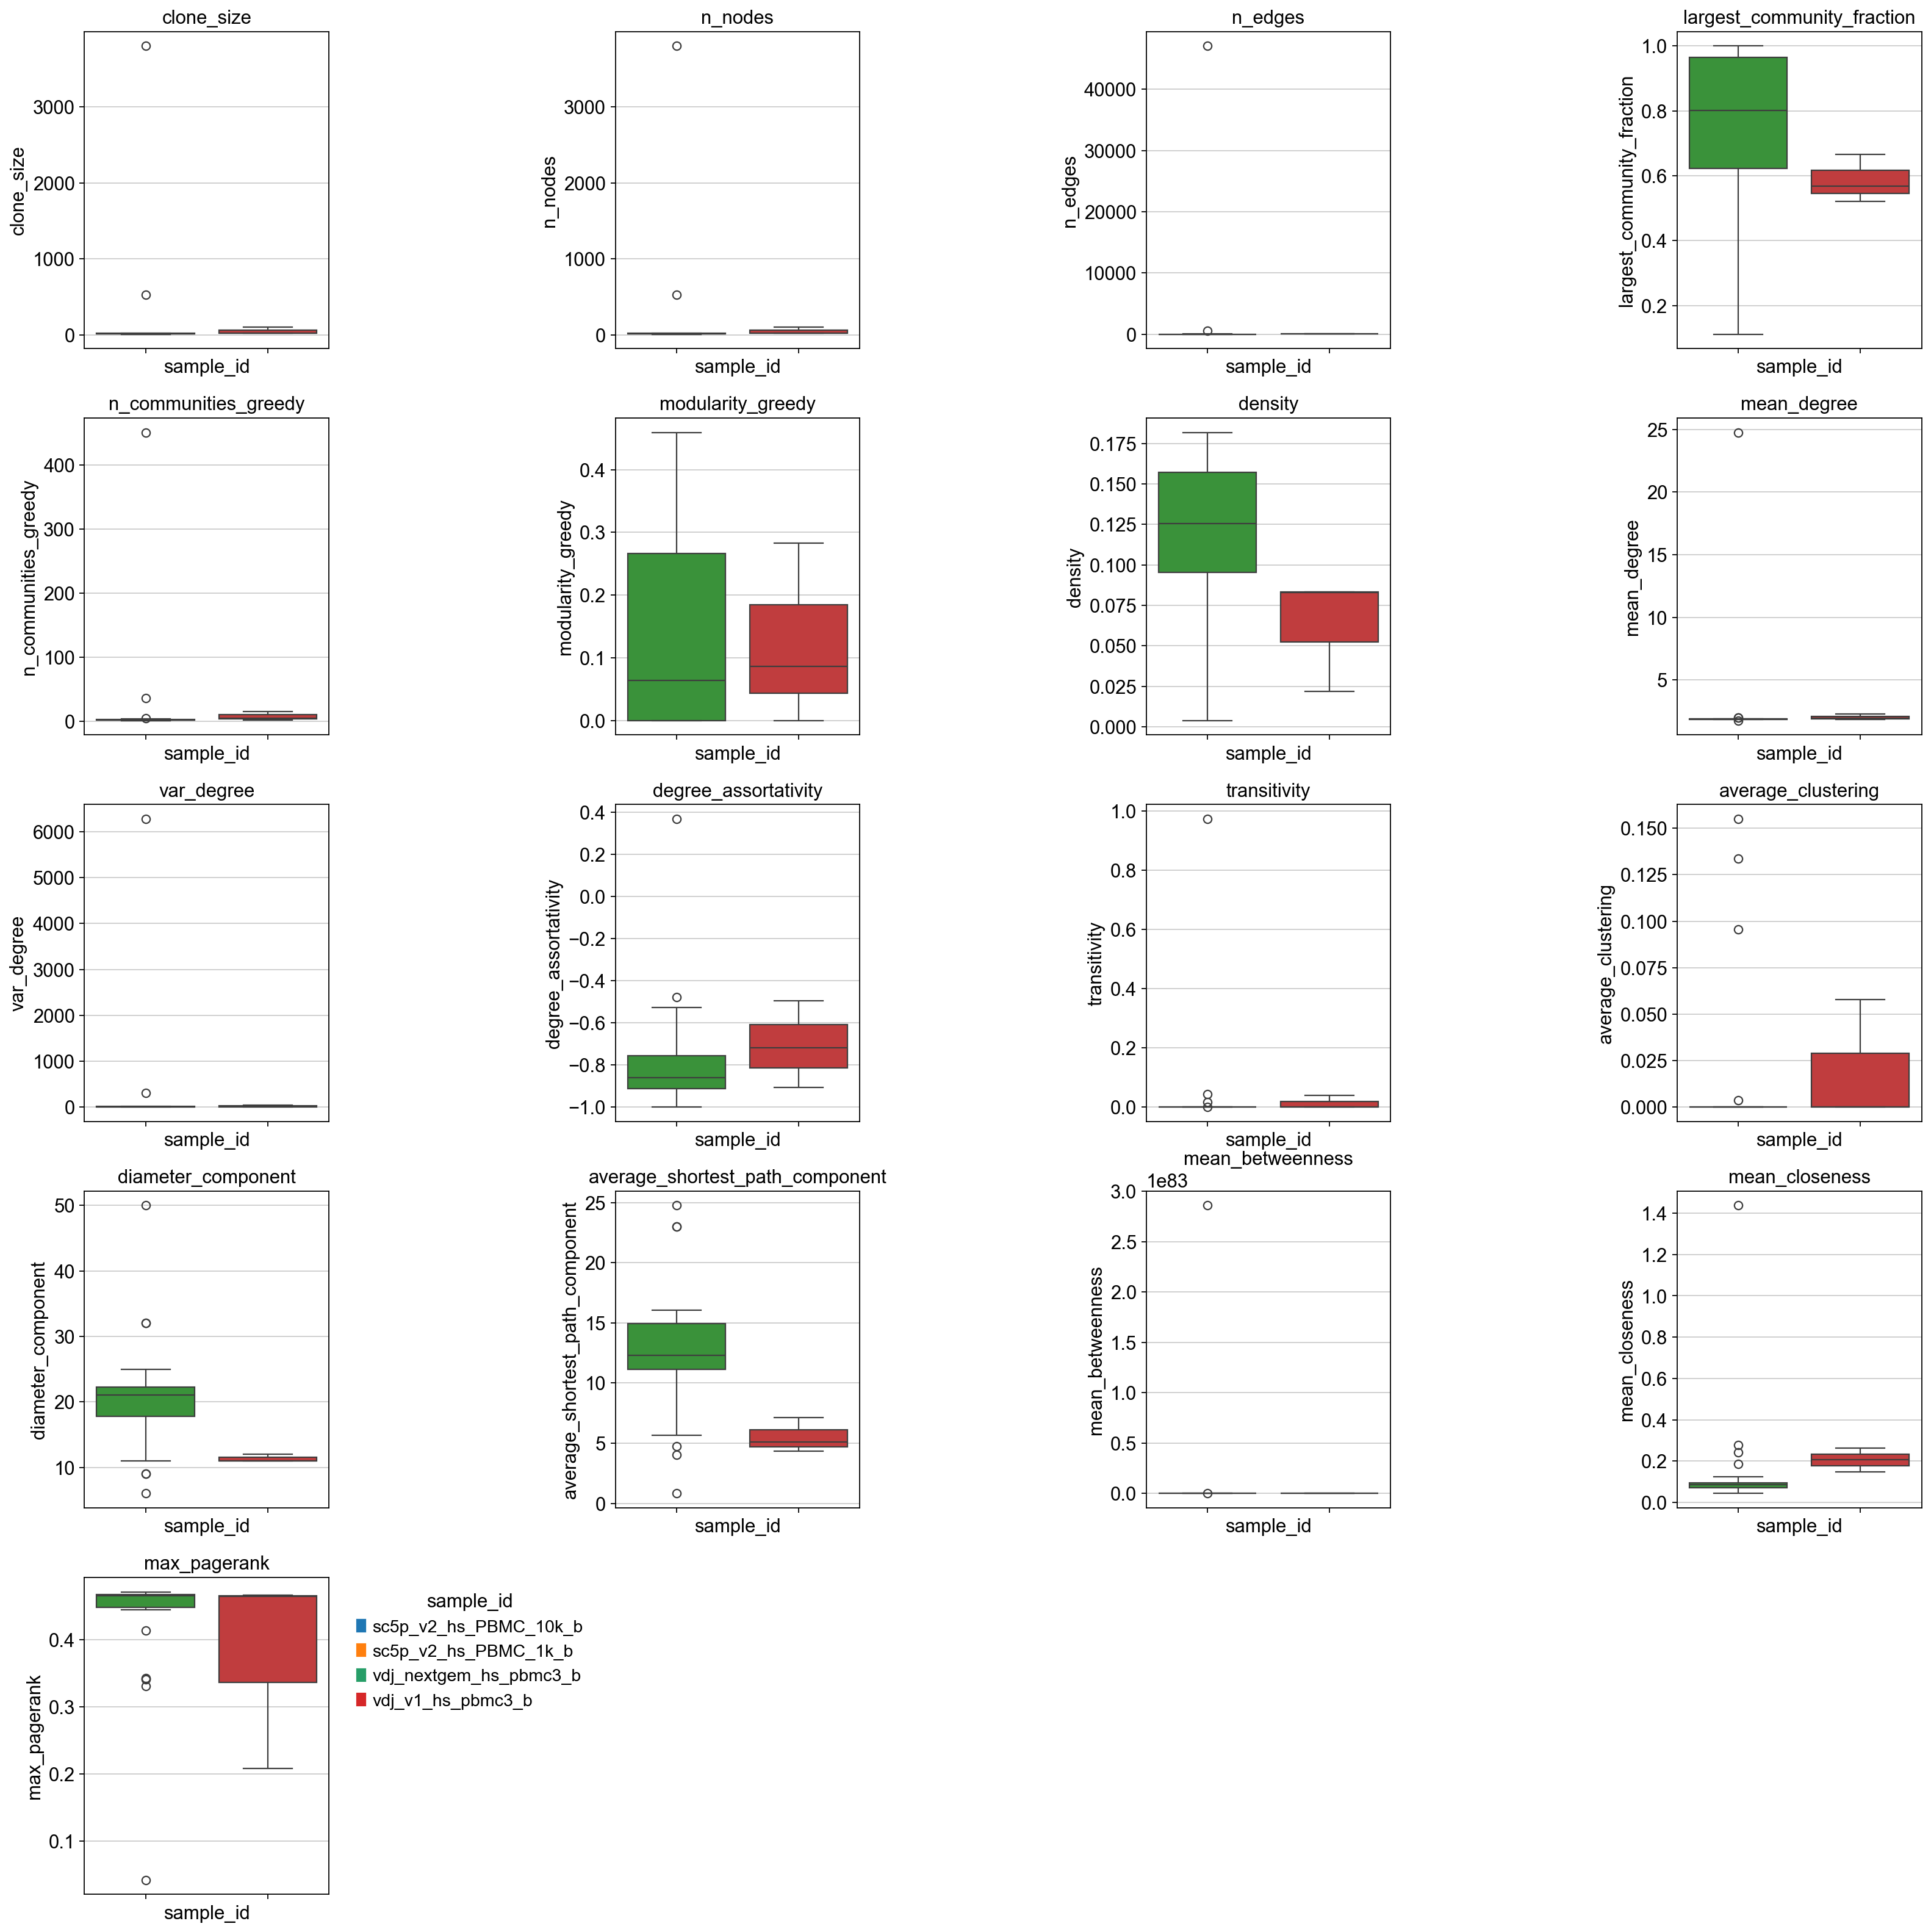

In [ ]:
import math
import matplotlib.patches as mpatches

cols = [
    "clone_size",
    "n_nodes",
    "n_edges",
    "largest_community_fraction",
    "n_communities_greedy",
    "modularity_greedy",
    "density",
    "mean_degree",
    "var_degree",
    "degree_assortativity",
    "transitivity",
    "average_clustering",
    "diameter_component",
    "average_shortest_path_component",
    "mean_betweenness",
    "mean_closeness",
    "max_pagerank",
]

df = intraclonal_metrics[intraclonal_metrics["clone_size"] > 10]

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    sns.boxplot(
        data=df,
        palette=palette,
        x="sample_id",
        y=col,
        ax=ax,
        legend=False,
    )

    ax.set_title(col)

    # hide x-axis tick labels
    ax.tick_params(axis="x", labelbottom=False)

# remove unused axes
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

# only show legend on last subplot
last_ax = axes[len(cols) - 1]

handles, labels = last_ax.get_legend_handles_labels()
if handles:
    last_ax.legend(handles, labels, loc="best")

unique_ids = sorted(adata_large.obs["sample_id"].unique())
colors = adata_large.uns["sample_id_colors"]

legend_handles = [
    mpatches.Patch(color=colors[i], label=uid)
    for i, uid in enumerate(unique_ids)
]
last_ax = axes[len(cols) - 1]
last_ax.legend(
    handles=legend_handles,
    title="sample_id",
    loc="best",
    bbox_to_anchor=(1.05, 1),
    frameon=False,
)

plt.tight_layout()
plt.show()

In [86]:
vdj_large

Lazy Dandelion object with n_obs = 10000 and n_contigs = 16196
    data: sequence_id, sequence, rev_comp, productive, v_call, d_call, j_call, sequence_alignment, germline_alignment, junction, junction_aa, v_cigar, d_cigar, j_cigar, stop_codon, vj_in_frame, locus, junction_length, np1_length, np2_length, v_sequence_start, v_sequence_end, v_germline_start, v_germline_end, d_sequence_start, d_sequence_end, d_germline_start, d_germline_end, j_sequence_start, j_sequence_end, j_germline_start, j_germline_end, v_score, v_identity, v_support, d_score, d_identity, d_support, j_score, j_identity, j_support, fwr1, fwr2, fwr3, fwr4, cdr1, cdr2, cdr3, cell_id, consensus_count, umi_count, v_call_10x, d_call_10x, j_call_10x, junction_10x, junction_10x_aa, j_call_blastn, j_identity_blastn, j_alignment_length_blastn, j_number_of_mismatches_blastn, j_number_of_gap_openings_blastn, j_sequence_start_blastn, j_sequence_end_blastn, j_germline_start_blastn, j_germline_end_blastn, j_support_blastn, j_score_bl